# LLMScholar-Personas — Metrics Pipeline

Implements the exact metrics from LLMScholarBench (Espín-Noboa & Méndez, 2026):
- **Diversity** (normalized Shannon entropy, Eq. 9)
- **Parity** (1 − TV distance, Eq. 11)
- **Factuality** (matched / unique names, Eq. 5)
- **Consistency** (pairwise Jaccard across runs, Eq. 4)
- **Duplicates** (1 − unique/total, Eq. 3)

**Known gaps (flagged):**
- `created_at` is NaN in factuality_full → using `run_id` for ordering
- Author language not available → `diversity_language` skipped
- Gender and geography only available for *found* authors

## Step 0 — Setup and data loading

In [38]:
from pathlib import Path
import sys
import glob
import hashlib
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

In [39]:
if '../..' not in sys.path:
    sys.path.append('../..')
    
%reload_ext autoreload
%autoreload 2

from libs.visuals.vis import sns_paper_style
from libs.visuals.grouped_metrics_leen import plot_grouped_metrics
from libs.visuals.grouped_metrics_leen import plot_grouped_metrics_labeled
from libs.metrics.constants import FIG_DPI

# Constants

## General

In [68]:
RESULTS      = Path('../../../results')
FACT_PATH    = RESULTS / 'summary/factuality_full.csv'
ETH_GT_GLOB  = str(RESULTS / 'ethnicity/DataFrameRankings_Genderize_Namsor_*_with_ethnicity.csv')
SS_GT_PATH   = Path('/data/datasets/LLMScholar-Personas/data/semantic_scholar_data/clean/Researchers_Deduplicated_Genderize_Namsor.parquet')
MODELS_METADATA_FN = '../../../data/models/metadata.json'

# FIG_DIR  = RESULTS / 'figures'
# PDF_DIR  = RESULTS / 'new_plots'
CACHE_DIR = RESULTS / '.cache'
# FIG_DIR.mkdir(parents=True, exist_ok=True)
# PDF_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

PLOTS_DIR = RESULTS / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

def _file_hash(*paths) -> str:
    """MD5 of mtime+size for each path — changes when any source file is updated."""
    parts = []
    for p in paths:
        p = Path(p)
        if p.exists():
            s = p.stat()
            parts.append(f"{p}:{s.st_size}:{int(s.st_mtime)}")
    return hashlib.md5("|".join(parts).encode()).hexdigest()[:10]


In [72]:
CALL_KEYS   = ['model', 'role', 'task', 'location', 'k', 'target', 'field', 'subfield', 'language', 'run_id']
PROMPT_KEYS = [c for c in CALL_KEYS if c != 'run_id']

MODEL_COLS = ['model_access','model_size','model_class','model_family']

VALID_FLAGS = {'cleaned', 'unchanged'}  # 'valid records' = cleaned + unchanged only
FACTUAL_AUTHOR_COL = 'author_found'     # SS-match OR OA-match (any source)

REFUSED_FLAG = 'refused'
ETHNICITY_ORDER = ['Asian', 'Black', 'White', 'Hispanic', 'American Indian']
GENDER_ORDER = ['Female', 'Male', 'Neutral']

ALL_METRICS = [
    # All-responses denominator
    'validity', 'refusals',
    
    # Valid-responses denominator
    'consistency', 
    'duplicates', 
    'factuality', 
    
    # Factual-records denominator
    'factuality_field', 'factuality_seniority', 'factuality_location',

    # Diversity
    'div_ethnicity', 'div_gender', 'div_location','div_productivity_works','div_productivity_citations',

    # Parity
    'parity_ethnicity', 'parity_gender','parity_works', 'parity_citations',

    # Productivity
    'pct_low_works', 'pct_med_works', 'pct_high_works', 
    'pct_low_citations', 'pct_med_citations', 'pct_high_citations',
    
    # popularity
    'popularity_works', 'popularity_citations',
]

# Bernoulli (binary 0/1) metrics — paper uses Wilson score CI here.
BINARY_METRICS = {'validity', 'refusals'}

NEEDED_COLS = (
    ['model', 'role', 'task', 'location', 'k', 'target', 'field', 'subfield', 'language', 'run_id']
    + ['valid_flag', 'name', 'lastname', 'author_status', 'oa_id',
       'perceived_ethnicity', 'gt_gender', 'location_oa_iso',
       'field_status', 'seniority_status', 'location_status',
       'oa_works_count', 'oa_cited_by_count']
)

PRODUCTIVITY_OA_FIELDS_MAP = {'oa_works_count': 'works', 
                              'oa_cited_by_count': 'citations'}
PRODUCTIVITY_TIER_LABELS = ['low', 'med', 'high']
PRODUCTIVITY_METRIC_COLS = [
    'parity_works', 
    'parity_citations',
    'popularity_works', 
    'popularity_citations',
    'pct_low_works',  
    'pct_med_works',  
    'pct_high_works',  
    'div_productivity_works',
    'pct_low_citations', 
    'pct_med_citations', 
    'pct_high_citations', 
    'div_productivity_citations',
]

FACTUALITY_METRICS   = ['factuality', 'factuality_field', 'factuality_seniority', 'factuality_location']
PARITY_METRICS = ['parity_ethnicity', 'parity_gender', 'parity_works', 'parity_citations']

TECHNICAL_METRICS = ['validity','refusals_c','duplicates_c'] + FACTUALITY_METRICS
SOCIAL_METRICS = PARITY_METRICS


## Normalization (english)

In [70]:
# ── Normalize field (population) to canonical English ─────────────────────
FIELD_NORM_MAP = {
    'Biología': 'Biology',   
    'Biologie': 'Biology',
    'Física':   'Physics',   
    'Physik':   'Physics',
    'Ciencias de la computación': 'Computer Science', 
    'Informatik': 'Computer Science',
    'Sociología': 'Sociology',  
    'Soziologie': 'Sociology',
    'Psicología': 'Psychology', 
    'Psychologie': 'Psychology',
    'Matemáticas': 'Mathematics', 
    'Mathematik': 'Mathematics',
}
# ── Normalize language to canonical English names ────────────────
LANGUAGE_NORM_MAP = {
    'english': 'English', 
    'german': 'German', 
    'spanish': 'Spanish',
    'English': 'English', 
    'German': 'German', 
    'Spanish': 'Spanish',
}
# ── Normalize location to canonical English ─────────────────────
LOCATION_NORM_MAP = {
    'Germany': 'Germany', 
    'Deutschland': 'Germany', 
    'Alemania': 'Germany',
    'Canada': 'Canada', 
    'Canadá': 'Canada', 
    'Kanada': 'Canada',
    'Japan': 'Japan', 
    'Japón': 'Japan', 
    'Japon': 'Japan',
    'South Africa': 'South Africa', 
    'Sudáfrica': 'South Africa',
    'Südafrika': 'South Africa', 
    'Sudafrica': 'South Africa',
    'Ecuador': 'Ecuador',
}
# ── Normalize task to canonical English ─────────────────────
TASK_NORM_MAP = {
    'buscando posibles contrataciones': 'seeking potential hires',
    'buscando un(a) asesor(a)':         'seeking an advisor',
    'potenzielle Einstellungen suchen': 'seeking potential hires',
    'einen Betreuer(in) suchen':        'seeking an advisor',
}
# ── Normalize target (seniority) to canonical English ─────────────────────
TARGET_NORM_MAP = {
    'Profesor(a) Sénior':  'Senior Professor', 'Seniorprofessor(in)': 'Senior Professor',
    'Profesor(a) Júnior':  'Junior Professor', 'Juniorprofessor(in)': 'Junior Professor',
}
# ── Normalize role to canonical English ─────────────────────
ROLE_NORM_MAP = {
    'PhD student':                   'PhD student',
    'Estudiante de doctorado':       'PhD student',
    'Doktorand(in)':                 'PhD student',
    'Director/Recruiter':            'Director/Recruiter',
    'Director(a)/Reclutador(a)':     'Director/Recruiter',
    'Direktor(in)/Rekrutierende(r)': 'Director/Recruiter',
}

## For Plots

In [71]:

ETHNICITY_MAP = {
        'White': 'White',
        'Asian': 'Asian',
        'Black or African American': 'Black',
        'Hispanic or Latino': 'Hispanic',
        'American Indian or Alaska Native': 'American Indian',
    }

MODEL_FAMILY_COLORS = {
    'deepseek': '#8B5CF6', 
    'gemma': '#EF4444', 
    'gemini': '#3B82F6',
    'gpt-4': '#10B981', 
    'gpt-oss': '#059669',
    'llama': '#F97316',
    'mistral': '#EC4899', 
    'mixtral': '#FBBF24',
    'olmo': '#92400E', 
    'phi': '#0EA5E9', 
    'qwq': '#84CC16', 
    'qwen': '#65A30D',
    'smollm': '#9CA3AF', 
    'yi': '#6D28D9',
    'dolphin': '#047857', 
    'falcon': '#1E3A5F',
}

TICK_COLOR = '#828282'

PLOT_LABELS = {
    'validity':                   'Validity',
    'refusals':                   'Refusals',
    'factuality':                 'Fact. $_{author}$',
    'factuality_field':           'Fact. $_{field}$',
    'factuality_seniority':       'Fact. $_{seniority}$',
    'factuality_location':        'Fact. $_{location}$',
    'consistency':                'Consistency',
    'duplicates':                 'Duplicates',
    'div_gender':                 'Div. $_{gen.}$',
    'div_ethnicity':              'Div. $_{eth.}$',
    'div_location':               'Div. $_{loc.}$',
    'div_productivity_works':     'Div. $_{pub.}$',
    'div_productivity_citations': 'Div. $_{cit.}$',
    'parity_gender':              'Parity $_{gender}$',
    'parity_ethnicity':           'Parity $_{eth.}$',
    'parity_works':               'Parity $_{pub.}$',
    'parity_citations':           'Parity $_{cit.}$',
    'popularity_works':           'Popularity $_{pub.}$',
    'popularity_citations':       'Popularity $_{cit.}$',
}

PLOT_METRICS = [
    # Output quality (response-level)
    'validity',
    'refusals',

    # Consistency / duplicates
    'consistency',
    'duplicates',

    # Factuality block
    'factuality',                    # author
    'factuality_field',
    'factuality_seniority',
    'factuality_location',
    
    # Diversity block (order: gender, ethnicity, publications, citations)
    'div_gender',
    'div_ethnicity',
    'div_location',
    'div_productivity_works',        # publications
    'div_productivity_citations',    # citations
    
    # Parity block — SAME order as diversity
    'parity_gender',                 # vs Semantic Scholar GT distribution
    'parity_ethnicity',              # vs Semantic Scholar GT distribution
    'parity_works',                  # publications, vs uniform 1/3 tier
    'parity_citations',              # citations, vs uniform 1/3 tier
    
    # Popularity (fraction in top productivity tier within field)
    'popularity_works',
    'popularity_citations',
]
PLOT_METRICS = [m for m in PLOT_METRICS if m in ALL_METRICS]

PLOT_TECHNICAL_METRICS = [m for m in PLOT_METRICS if m in ['validity','refusals','consistency','duplicates'] or m.startswith('factuality')]
PLOT_SOCIAL_METRICS = [m for m in PLOT_METRICS if m.startswith(('div_','parity_','popularity_'))]
METRIC_TYPES = {'technical': PLOT_TECHNICAL_METRICS, 'social': PLOT_SOCIAL_METRICS}

PLOT_DIRS = {
    'validity':                    '↑',
    'refusals':                    '↓',
    'factuality':                  '↑',
    'factuality_field':            '↑',
    'factuality_seniority':        '↑',
    'factuality_location':         '↑',
    'consistency':                 None,
    'duplicates':                  '↓',
    'div_gender':                  None,
    'div_ethnicity':               None,
    'div_location':                None,
    'div_productivity_works':      None,
    'div_productivity_citations':  None,
    'parity_gender':               '↑',
    'parity_ethnicity':            '↑',
    'parity_works':                '↑',
    'parity_citations':            '↑',
    'popularity_works':            None,
    'popularity_citations':        None,
}

LANGUAGE_ORDER = ['English', 'Spanish', 'German']
LANGUAGE_MAP = {'Spanish':'es', 'German':'de', 'English':'en'}
LANGUAGE_COLORS = {'English': '#4A90D9', 'Spanish': '#E8A838', 'German': '#5DB85D'}

LOCATION_ORDER = ['Ecuador', 'Germany', 'Japan', 'Canada', 'South Africa']
LOCATION_MAP = {'Ecuador':'ECU', 'Germany':'DEU', 'Japan':'JPN', 'Canada':'CAN', 'South Africa':'ZAF'}
LOCATION_COLORS = {
    'Ecuador': '#E8A838',  'Germany': '#5DB85D',  'Japan':  '#C0392B',
    'Canada':  '#4A90D9',  'South Africa': '#8E44AD',
}

FIELD_ORDER = ['Biology', 'Computer Science', 'Mathematics', 'Physics', 'Psychology', 'Sociology']
FIELD_MAP = {'Sociology': 'Soc.', 'Psychology': 'Psyc.', 'Mathematics': 'Math.', 'Biology': 'Bio.', 'Computer Science': 'CS', 'Physics': 'Phys.'}
FIELD_COLORS = {
    'Biology': '#27AE60', 'Computer Science': '#2980B9', 'Mathematics': '#8E44AD',
    'Physics': '#E67E22', 'Psychology': '#C0392B',       'Sociology':   '#16A085',
}

SENIORITY_ORDER = ['Junior Professor', 'Senior Professor']
SENIORITY_MAP = {'Junior Professor': 'Junior', 'Senior Professor': 'Senior'}
SENIORITY_COLORS = {'Junior Professor': '#E8703A', 'Senior Professor': '#C0392B'}

ROLE_ORDER = ['PhD student', 'Director/Recruiter']
ROLE_MAP = {'PhD student': 'Student', 'Director/Recruiter': 'Recruiter'}
ROLE_COLORS = {'PhD student': '#2980B9', 'Director/Recruiter': '#E67E22'}

TASK_ORDER = ['seeking an advisor', 'seeking potential hires']
TASK_COLORS = {'seeking an advisor': '#8E44AD', 'seeking potential hires': '#2980B9'}
TASK_MAP = {'seeking an advisor': 'Advisor search', 'seeking potential hires': 'Candidate search'}

SIZE_ORDER   = ['T', 'S', 'M', 'L', 'XL']
SIZE_MAP = {'T': 'Tiny', 'S': 'Small', 'M': 'Medium', 'L': 'Large', 'XL': 'XL'}
SIZE_MAP_REV = {v:k for k,v in SIZE_MAP.items()}
SIZE_COLORS = {'T': '#2ECC71', 'S': '#3498DB', 'M': '#9B59B6', 'L': '#E67E22', 'XL': '#E74C3C'}

ACCESS_ORDER = ['open-weight', 'proprietary']
ACCESS_MAP = {'open-weight': 'Open', 'proprietary': 'Proprietary'}

MODEL_ARCHITECTURE_MAP = {'model_access': 'Access', 'model_size': 'Size', 'model_class': 'Reasoning'}

REASONING_ORDER = [True, False]

K_ORDER = [1, 5, 10]
K_COLORS = {1: '#2980B9', 5: '#E67E22', 10: '#8E44AD'}

FIG_WIDTH = 15
FIG_HEIGHT = 1.0
FIG_SIZE = (FIG_WIDTH, FIG_HEIGHT) 

PLOTS_DIR


PosixPath('../../../results/plots')

# Legend

| Variable | Description | Usage |
|---|---|---|
|`df_all_recommendations` | All recommendations (recommended names per call) | Only in the beginning |
|`df_all_calls` | All calls (run_ids) with metrics (similar as recommendations without recommeded names) | For validity and Refusals |
|`df_gt`| Researchers' names from Semantic Scholar (includes gender and ethinicity )| To compute factuality and social metrics |
|`df_valid_recommendations` | All recommendations whose calls are valid | For factuality author | 
|`df_valid_recommendations_cid` | Same as above, but with cid | ... |
|`df_valid_calls` | All valid responses (includes all metric values) | ... |



# Load Data

In [4]:

_df_cache = CACHE_DIR / f"df_{_file_hash(FACT_PATH)}.pkl"

if _df_cache.exists():
    # Cache may pre-date the oa_id addition — verify it has the required cols
    print(f'Loading cached df ({_df_cache.name}) ...')
    df_all_recommendations = pd.read_pickle(_df_cache)
    missing = [c for c in NEEDED_COLS if c not in df_all_recommendations.columns]
    if missing:
        print(f'  Cached df is missing {missing} — reloading from CSV')
        df_all_recommendations = pd.read_csv(FACT_PATH, usecols=NEEDED_COLS, low_memory=False)
        df_all_recommendations.to_pickle(_df_cache)
else:
    print('Loading factuality_full.csv (selected columns only) ...')
    df_all_recommendations = pd.read_csv(FACT_PATH, usecols=NEEDED_COLS, low_memory=False)
    df_all_recommendations.to_pickle(_df_cache)
    print(f'  Cached → {_df_cache.name}')

print(f"Total recommendations: {len(df_all_recommendations)}")
print(df_all_recommendations[CALL_KEYS].drop_duplicates().shape[0], "unique calls")

# Total recommendations: 3907448
# 928800 unique calls


Loading cached df (df_96e9d23165.pkl) ...
Total recommendations: 3907448
928800 unique calls


## Pre-processing

In [5]:
# Update model metadata
import json
from collections import defaultdict
import pandas as pd

# 1. load models' metadata
models_metadata = json.load(open(MODELS_METADATA_FN, 'r'))
len(models_metadata)

# 2. create a df
tmp = pd.DataFrame.from_dict(models_metadata, orient='index')
tmp = tmp.reset_index().rename(columns={'index': 'model'})[['model','size']]
tmp.loc[:,'model'] = tmp.model.apply(lambda x:x.replace('-q4_K_M',''))

# Group models by size
grouped = defaultdict(list)

SIZE_ORDER = ['T', 'S', 'M', 'L', 'XL']

for size in SIZE_ORDER:
    grouped[size] = tmp.loc[tmp["size"] == size, "model"].tolist()

# Pad columns to equal length
max_len = max(len(grouped[s]) for s in SIZE_ORDER)

for s in SIZE_ORDER:
    grouped[s] += [""] * (max_len - len(grouped[s]))

# Create reshaped dataframe
latex_df = pd.DataFrame({s: grouped[s] for s in SIZE_ORDER})

# Escape underscores for LaTeX
latex_df = latex_df.map(
    lambda x: x.replace("_", r"\_") if isinstance(x, str) else x
)

# Generate LaTeX table
latex_table = latex_df.to_latex(
    index=False,
    escape=False,
    column_format="lllll",
    caption="Models grouped by size category.",
    label="tab:model_sizes"
)

print(latex_table)

# update in data
mk = list(models_metadata.keys())[0]
df_all_recommendations.loc[:,'model'] = df_all_recommendations.model.apply(lambda x: x.replace(":",'-').replace(".","_"))
df_all_recommendations.loc[:, 'model_size'] = df_all_recommendations['model'].map(lambda m: models_metadata[m]['size'] if m in models_metadata else 'Unknown')
df_all_recommendations.loc[:, 'model_access'] = df_all_recommendations['model'].map(lambda m: models_metadata[m]['access'] if m in models_metadata else 'Unknown')
df_all_recommendations.loc[:, 'model_class'] = df_all_recommendations['model'].map(lambda m: models_metadata[m]['reasoning'] if m in models_metadata else 'Unknown')
df_all_recommendations.loc[:, 'model_family'] = df_all_recommendations['model'].map(lambda m: models_metadata[m]['family'] if m in models_metadata else 'Unknown')
df_all_recommendations.model_size.value_counts()

\begin{table}
\caption{Models grouped by size category.}
\label{tab:model_sizes}
\begin{tabular}{lllll}
\toprule
T & S & M & L & XL \\
\midrule
gemini-2\_5-flash-lite & gemini-2\_5-flash & falcon3-10b-instruct & deepseek-r1-70b-llama-distill & qwen3-235b-a22b-instruct-2507 \\
smollm2-1\_7b-instruct & gemma3n-e4b-it & mistral-nemo-12b-instruct-2407 & llama3\_3-70b-instruct & llama4-17b-maverick-128e-instruct \\
dolphin-phi-2\_7b-v2\_6 & mistral-7b-instruct-v0\_3 & olmo2-13b-1124-instruct & llama4-17b-scout-16e-instruct &  \\
llama3\_2-3b-instruct & olmo2-7b-1124-instruct & phi4-14b & gpt-oss-120b &  \\
phi4-mini-3\_8b & falcon3-7b-instruct & phi4-reasoning-14b & mistral-large-123b-instruct-2411 &  \\
gemma3-4b-it & dolphin3-8b-llama3\_1 & gemini-2\_5-pro & mixtral-8x22b-instruct-v0\_1 &  \\
gpt-4\_1-nano-2025-04-14 & deepseek-r1-8b-0528-qwen3 & gpt-oss-20b & dolphin-mixtral-8x22b-v2\_9 &  \\
 & qwen3-8b & mistral-small-22b-instruct-2409 & gpt-4\_1-2025-04-14 &  \\
 & yi-9b-chat-v1\_5 & 

model_size
M     1444409
S      938458
L      830214
T      559936
XL     134431
Name: count, dtype: int64

In [6]:
# ── Derive "either" author_found: matched in Semantic Scholar OR OpenAlex ────
# `author_status == 'found'` reflects only the Semantic Scholar match; the
# OpenAlex enrichment step (oa_id) was applied AFTER and isn't folded back
# into author_status. The paper definition is "found in either source" — so we
# OR the two signals here and use this as the factuality denominator.
df_all_recommendations['author_found'] = (
    (df_all_recommendations['author_status'] == 'found') |
    df_all_recommendations['oa_id'].notna() & (df_all_recommendations['oa_id'].astype(str) != '')
)
df_all_recommendations.author_found.value_counts(), df_all_recommendations.author_found.value_counts(normalize=True)

(author_found
 True     3620502
 False     286946
 Name: count, dtype: int64,
 author_found
 True    0.9266
 False   0.0734
 Name: proportion, dtype: float64)

In [11]:
df_all_calls

valid_flag
model                               role                      task                             location     k  target             field     subfield language run_id model_access model_size model_class model_family           
deepseek-r1-32b-qwen-distill-q4_K_M Director(a)/Reclutador(a) buscando posibles contrataciones Alemania     1  Profesor(a) Júnior Biología  Anatomía spanish  1      open-weight  M          True        deepseek      unchanged
                                                                                                                                                              2      open-weight  M          True        deepseek          empty
                                                                                                                                                              3      open-weight  M          True        deepseek      unchanged
                                                                                                                                                              4      open-weight  M          True        deepseek        cleaned
                                                                                                                                                              5      open-weight  M          True        deepseek        cleaned
...                                                                                                                                                                                                                          ...
yi-9b-chat-v1_5-q4_K_M              PhD student               seeking an advisor               South Africa 10 Senior Professor   Sociology Family   english  6      open-weight  S          False       yi            unchanged
                                                                                                                                                              7      open-weight  S          False       yi            unchanged
                                                                                                                                                              8      open-weight  S          False       yi            unchanged
                                                                                                                                                              9      open-weight  S          False       yi            unchanged
                                                                                                                                                              10     open-weight  S          False       yi              cleaned

[928800 rows x 1 columns]

In [12]:
# ── valid_flag totals PER RESPONSE ───────────────────────────────────────────
# The dataframe has one row per AUTHOR (responses with k authors get exploded
# into k rows). `valid_flag` is set once per RESPONSE and replicated across
# those rows. Always count flags at the response/call level — collapse first
# with groupby + .first() over CALL_KEYS.
df_all_calls = df_all_recommendations.groupby(CALL_KEYS + MODEL_COLS, dropna=False)[['valid_flag']].first() #.reset_index()
n_calls = len(df_all_calls)

print(f'\n  Rows (author-level, k-exploded): {len(df_all_recommendations):,}')
print(f'  Responses (one per LLM call):    {n_calls:,}')
print(f'  Columns: {len(df_all_recommendations.columns)}')

print(f'\n  valid_flag totals per response:')
_vc = df_all_calls.valid_flag.value_counts()
_pc = df_all_calls.valid_flag.value_counts(normalize=True) * 100
print(f'    {"flag":<12s}  {"responses":>10s}  {"%":>7s}')
print(f'    {"-"*12}  {"-"*10}  {"-"*7}')
for flag, n in _vc.items():
    print(f'    {str(flag):<12s}  {n:>10,}  {_pc[flag]:>6.2f}%')
print(f'    {"-"*12}  {"-"*10}  {"-"*7}')
print(f'    {"TOTAL":<12s}  {n_calls:>10,}  {100.0:>6.2f}%')

print(f'\n  author_status (SS-only): found={(df_all_recommendations["author_status"]=="found").mean():.4f}')
print(f'  author_found  (SS or OA): found={df_all_recommendations["author_found"].mean():.4f}')
print(f'  → {(df_all_recommendations["author_found"] & (df_all_recommendations["author_status"]!="found")).sum():,} '
      f'rows reclassified from hallucinated → found via OpenAlex')

# OA productivity columns (oa_works_count, oa_cited_by_count) come from the
# same factuality_full.csv now — they're propagated forward from the OpenAlex
# enrichment step. No separate merge needed.
print(f'\nOA productivity coverage:')
for c in ['oa_works_count', 'oa_cited_by_count']:
    print(f'  {c:25s}  {df_all_recommendations[c].notna().mean():.4f}')

# MODELS
print(f'\n  model architecture')
_df_all_calls = df_all_calls.reset_index()
for c in MODEL_COLS:
    print(f'  {c}:')
    _vc = _df_all_calls[c].value_counts()
    _pc = _df_all_calls[c].value_counts(normalize=True) * 100
    print(f'    {"flag":<12s}  {"responses":>10s}  {"%":>7s}')
    for flag, n in _vc.items():
        print(f'    {str(flag):<12s}  {n:>10,}  {_pc[flag]:>6.2f}%')



  Rows (author-level, k-exploded): 3,907,448
  Responses (one per LLM call):    928,800
  Columns: 28

  valid_flag totals per response:
    flag           responses        %
    ------------  ----------  -------
    cleaned          439,692   47.34%
    unchanged        360,773   38.84%
    invalid           53,679    5.78%
    refused           48,906    5.27%
    empty             20,873    2.25%
    fixed_dict         4,877    0.53%
    ------------  ----------  -------
    TOTAL            928,800  100.00%

  author_status (SS-only): found=0.8708
  author_found  (SS or OA): found=0.9266
  → 217,942 rows reclassified from hallucinated → found via OpenAlex

OA productivity coverage:
  oa_works_count             0.8610
  oa_cited_by_count          0.8610

  model architecture
  model_access:
    flag           responses        %
    open-weight      799,200   86.05%
    proprietary      129,600   13.95%
  model_size:
    flag           responses        %
    M                345,600

## Semantic Scholar GT

In [13]:
# ── Ground truth: ethnicity from CSVs (3 cols only), gender from parquet ──────
gt_files = sorted(glob.glob(ETH_GT_GLOB))
if not gt_files:
    raise FileNotFoundError(f'No ground-truth files matched:\n  {ETH_GT_GLOB}')

_gt_cache = CACHE_DIR / f"gt_{_file_hash(SS_GT_PATH, *gt_files)}.pkl"

if _gt_cache.exists():
    print(f'Loading cached gt ({_gt_cache.name}) ...')
    df_gt = pd.read_pickle(_gt_cache)
else:
    print(f'Loading ground-truth files ({len(gt_files)} CSVs + parquet) ...')
    gt_parts = [
        pd.read_csv(f, usecols=['Researcher_id', 'Year', 'perceived_ethnicity'])
        for f in gt_files
    ]
    df_gt = pd.concat(gt_parts, ignore_index=True)
    del gt_parts

    df_gt = df_gt.sort_values('Year').groupby('Researcher_id').last().reset_index()

    gt_parquet = pd.read_parquet(SS_GT_PATH, columns=['Researcher_id', 'Combined_gender'])
    df_gt = df_gt.merge(gt_parquet, on='Researcher_id', how='left')
    del gt_parquet

    df_gt['gender_clean'] = df_gt['Combined_gender'].str.strip().str.lower().map(
        {'male': 'Male', 'female': 'Female', 'unisex': 'Neutral'}
    )
    df_gt['ethnicity_clean'] = df_gt['perceived_ethnicity'].map(ETHNICITY_MAP)

    df_gt.to_pickle(_gt_cache)
    print(f'  Cached → {_gt_cache.name}')

# Make ETHNICITY_MAP available to downstream cells (needed even on cache hit)
print(f'GT researchers (deduplicated): {len(df_gt):,}')
print('\nGT ethnicity distribution (excl. Unknown):')
gt_eth_dist = (df_gt['ethnicity_clean'].value_counts(normalize=True)
                 .rename('fraction').rename_axis('ethnicity'))
print(gt_eth_dist.to_string())
print('\nGT gender distribution (excl. Unknown):')
gt_gen_dist = (df_gt['gender_clean'].dropna().value_counts(normalize=True)
                 .rename('fraction').rename_axis('gender'))
print(gt_gen_dist.to_string())


Loading cached gt (gt_7913d1dede.pkl) ...
GT researchers (deduplicated): 6,686,108

GT ethnicity distribution (excl. Unknown):
ethnicity
White      0.3845
Asian      0.3746
Hispanic   0.1657
Black      0.0752

GT gender distribution (excl. Unknown):
gender
Male     0.6751
Female   0.3249


In [23]:
# ── Per-call binary indicators (validity / refusals) — PER RESPONSE ──────────
# `valid_flag` is set at the response/call level by batch_parse_results.py
# (one flag per LLM response). When the response is a list of authors, that
# same flag is replicated across the k exploded rows. Verified empirically:
# every group of CALL_KEYS has exactly one distinct `valid_flag` value.
#
# Therefore: collapse to one row per call with `.first()` BEFORE computing
# rates. Computing them at row level would over-weight valid responses
# (~5 rows/call) vs invalid/refused/empty ones (1 row/call), inflating
# validity and deflating refusals.


# Verify the per-response invariant before relying on .first()
_n_distinct_per_call = df_all_recommendations.groupby(CALL_KEYS, dropna=False)['valid_flag'].nunique()
assert (_n_distinct_per_call <= 1).all(), (
    f"valid_flag is NOT constant per call in "
    f"{(_n_distinct_per_call > 1).sum()} call groups — "
    f"the per-response assumption is broken."
)
print(f'✓ valid_flag is per response: every call has a single flag value')

# call_flags_full = (
#     df_all_recommendations.groupby(CALL_KEYS, dropna=False)['valid_flag']
#       .first()
#       .reset_index()
# )

df_all_calls = df_all_calls.reset_index()
df_all_calls['validity'] = df_all_calls['valid_flag'].isin(VALID_FLAGS).astype(int)
df_all_calls['refusals'] = (df_all_calls['valid_flag'] == REFUSED_FLAG).astype(int)

# Per-response totals and rates (denominator = responses, NOT rows)
n_calls = len(df_all_calls)
print(f'\nTotal responses (incl. invalid/refused): {n_calls:,}')
print(f'  valid    responses: {int(df_all_calls["validity"].sum()):>8,}  '
      f'({df_all_calls["validity"].mean()*100:5.2f}%)')
print(f'  refused  responses: {int(df_all_calls["refusals"].sum()):>8,}  '
      f'({df_all_calls["refusals"].mean()*100:5.2f}%)')


# ── Filter to valid responses only ───────────────────────────────────────────
df_valid_recommendations = df_all_recommendations[df_all_recommendations['valid_flag'].isin(VALID_FLAGS)].copy()
print(f'\nValid rows (author-level, k-exploded): {len(df_valid_recommendations):,} / {len(df_all_recommendations):,}  '
      f'({len(df_valid_recommendations)/len(df_all_recommendations)*100:.1f}%)')

# Normalize ethnicity labels to match GT
df_valid_recommendations['ethnicity_clean'] = df_valid_recommendations['perceived_ethnicity'].map(ETHNICITY_MAP)

# Normalize gender (from gt_gender, available for found authors only)
df_valid_recommendations['gender_clean'] = df_valid_recommendations['gt_gender'].str.strip().str.lower().map(
    {'male': 'Male', 'female': 'Female', 'unisex': 'Neutral'}
)

# Author identifier per call
df_valid_recommendations['author_id'] = df_valid_recommendations['name'].fillna('') + ' ' + df_valid_recommendations['lastname'].fillna('')
df_valid_recommendations['author_id'] = df_valid_recommendations['author_id'].str.strip()

print(f'\nMissing ethnicity after mapping: {df_valid_recommendations["ethnicity_clean"].isna().sum()} ({df_valid_recommendations["ethnicity_clean"].isna().sum() * 100 / len(df_valid_recommendations):.2f}%)')
print(f'Missing gender (expected — only found authors have it): {df_valid_recommendations["gender_clean"].isna().sum()}, / {len(df_valid_recommendations)} ({df_valid_recommendations["gender_clean"].isna().sum() * 100 / len(df_valid_recommendations):.2f}%)')
print(f'Missing location_oa_iso (expected — only found authors): {df_valid_recommendations["location_oa_iso"].isna().sum()}, / {len(df_valid_recommendations)} ({df_valid_recommendations["location_oa_iso"].isna().sum() * 100 / len(df_valid_recommendations):.2f}%)')


✓ valid_flag is per response: every call has a single flag value

Total responses (incl. invalid/refused): 928,800
  valid    responses:  800,465  (86.18%)
  refused  responses:   48,906  ( 5.27%)

Valid rows (author-level, k-exploded): 3,741,367 / 3,907,448  (95.7%)

Missing ethnicity after mapping: 1708493 (45.66%)
Missing gender (expected — only found authors have it): 535636, / 3741367 (14.32%)
Missing location_oa_iso (expected — only found authors): 690929, / 3741367 (18.47%)


## Step 1 — Per-call metric functions

### Populations per metric family

The dataframe has TWO denominators that matter:

| Family | Population | Filter |
|---|---|---|
| **Refusals**, **Validity** | **All responses** (= one row per LLM call, 928,800) | none — count every attempt |
| **Duplicates**, **Consistency**, **Factuality** (author / field / seniority / location) | **Valid responses only** | `valid_flag ∈ {cleaned, unchanged}` → `valid` |
| **Diversity** (gender, ethnicity, publications, citations), **Parity** (gender, ethnicity, publications, citations), **Popularity** (publications, citations) | **Factual records only** (authors that exist in SS or OA) | `valid_flag ∈ {cleaned, unchanged}` AND `author_found == True` → `found` |

The exploded row count (~3.9M) is NEVER used as a denominator. Validity/refusals collapse to one row per call first (see Step 0); per-call metrics use `_cid` keyed by `CALL_KEYS`.


In [25]:
# ── Build per-call metrics table (vectorized) ─────────────────────────────────
gt_eth_frac = (df_gt['ethnicity_clean'].dropna().value_counts(normalize=True).reindex(ETHNICITY_ORDER, fill_value=0))
gt_gen_frac = (df_gt['gender_clean'].dropna().value_counts(normalize=True).reindex(GENDER_ORDER, fill_value=0))

print('Computing per-call metrics (vectorized) ...')

# Surrogate integer key per unique call — handles NaN in CALL_KEYS safely
df_valid_recommendations['_cid'] = df_valid_recommendations.groupby(CALL_KEYS, dropna=False).ngroup()
n_calls = df_valid_recommendations['_cid'].nunique()
print(f'Total valid calls: {n_calls:,}')

# ── Base counts ───────────────────────────────────────────────────────────────
n_total_recommendations  = df_valid_recommendations.groupby('_cid').size().rename('n_total_recommendations')

uniq     = df_valid_recommendations.drop_duplicates(['_cid', 'author_id'])
n_unique_authors = uniq.groupby('_cid').size().rename('n_unique_authors')

# Use the "either" flag: an author is real if matched in Semantic Scholar OR OpenAlex.
df_authors_found    = uniq[uniq['author_found']]
n_authors_found  = df_authors_found.groupby('_cid').size().rename('n_authors_found')

# One row per call with the original CALL_KEYS values
# call_keys_df = 
df_valid_recommendations_cid = (df_valid_recommendations[CALL_KEYS + ['_cid'] + MODEL_COLS]
                                .drop_duplicates('_cid')
                                .set_index('_cid'))

df_valid_calls = (df_valid_recommendations_cid
                    .join(n_total_recommendations)
                    .join(n_unique_authors, how='left')
                    .join(n_authors_found,  how='left')
                    .fillna({'n_unique_authors': 0, 'n_authors_found': 0})
                    .astype({'n_unique_authors': int, 'n_authors_found': int}))

df_valid_calls['duplicates'] = df_valid_calls.apply(lambda row: (1-row['n_unique_authors']/row['n_total_recommendations']), axis=1)
df_valid_calls['factuality'] = np.where(df_valid_calls['n_unique_authors'] > 0, df_valid_calls['n_authors_found'] / df_valid_calls['n_unique_authors'], np.nan)

# ── Field match ───────────────────────────────────────────────────────────────
fe          = df_authors_found[df_authors_found['field_status'].isin(['field_match', 'field_mismatch'])]
field_eval  = fe.groupby('_cid').size().rename('_fe')
field_match = (fe[fe['field_status'] == 'field_match']
               .groupby('_cid').size().rename('_fm'))
df_valid_calls       = df_valid_calls.join(field_eval).join(field_match)
df_valid_calls['factuality_field'] = df_valid_calls['_fm'] / df_valid_calls['_fe'].replace(0, np.nan)
df_valid_calls.drop(columns=['_fe', '_fm'], inplace=True)

# ── Seniority match ───────────────────────────────────────────────────────────
se         = df_authors_found[df_authors_found['seniority_status'].isin(['seniority_match', 'seniority_mismatch'])]
sen_eval   = se.groupby('_cid').size().rename('_se')
sen_match  = (se[se['seniority_status'] == 'seniority_match']
              .groupby('_cid').size().rename('_sm'))
df_valid_calls      = df_valid_calls.join(sen_eval).join(sen_match)
df_valid_calls['factuality_seniority'] = df_valid_calls['_sm'] / df_valid_calls['_se'].replace(0, np.nan)
df_valid_calls.drop(columns=['_se', '_sm'], inplace=True)

# ── Location match (analogous to field/seniority) ────────────────────────────
le         = df_authors_found[df_authors_found['location_status'].isin(['location_match', 'location_mismatch'])]
loc_eval   = le.groupby('_cid').size().rename('_le')
loc_match  = (le[le['location_status'] == 'location_match']
              .groupby('_cid').size().rename('_lm'))
df_valid_calls      = df_valid_calls.join(loc_eval).join(loc_match)
df_valid_calls['factuality_location'] = df_valid_calls['_lm'] / df_valid_calls['_le'].replace(0, np.nan)
df_valid_calls.drop(columns=['_le', '_lm'], inplace=True)

# ── Diversity helpers ─────────────────────────────────────────────────────────
def _div_fixed(found_df, cat_col, cats):
    """Normalized Shannon entropy with a fixed category set."""
    known  = found_df[found_df[cat_col].notna()]
    counts = (known.groupby(['_cid', cat_col])
              .size().unstack(cat_col, fill_value=0)
              .reindex(columns=cats, fill_value=0))
    total  = counts.sum(axis=1)
    p      = counts.div(total.replace(0, np.nan), axis=0)
    entropy = -(p * np.log(p.where(p > 0))).sum(axis=1)
    div    = entropy / np.log(len(cats))
    div[total < 2] = np.nan
    return div

def _div_geo(found_df):
    """Normalized Shannon entropy with variable category count (location)."""
    known = found_df[found_df['location_oa_iso'].notna()]
    if known.empty:
        return pd.Series(dtype=float, name='div_location')
    counts  = known.groupby(['_cid', 'location_oa_iso']).size()
    totals  = counts.groupby(level='_cid').transform('sum')
    p       = counts / totals
    entropy = (-(p * np.log(p))).groupby(level='_cid').sum()
    n_cats  = counts.groupby(level='_cid').count()
    log_n   = np.log(n_cats.where(n_cats >= 2))
    return (entropy / log_n).rename('div_location')

def _parity(found_df, cat_col, cats, gt_frac):
    """1 − TV distance vs ground-truth distribution."""
    known  = found_df[found_df[cat_col].notna()]
    counts = (known.groupby(['_cid', cat_col])
              .size().unstack(cat_col, fill_value=0)
              .reindex(columns=cats, fill_value=0))
    total  = counts.sum(axis=1)
    frac   = counts.div(total.replace(0, np.nan), axis=0).fillna(0)
    tv     = 0.5 * (frac - gt_frac).abs().sum(axis=1)
    return 1 - tv

# ── Compute diversity & parity ────────────────────────────────────────────────
df_valid_calls['div_ethnicity']    = _div_fixed(df_authors_found, 'ethnicity_clean', ETHNICITY_ORDER)
df_valid_calls['div_gender']       = _div_fixed(df_authors_found, 'gender_clean',    GENDER_ORDER)
df_valid_calls['div_location']     = _div_geo(df_authors_found)
df_valid_calls['parity_ethnicity'] = _parity(df_authors_found, 'ethnicity_clean', ETHNICITY_ORDER, gt_eth_frac)
df_valid_calls['parity_gender']    = _parity(df_authors_found, 'gender_clean',    GENDER_ORDER, gt_gen_frac)

df_valid_calls = df_valid_calls.reset_index(drop=True)
df_valid_recommendations.drop(columns=['_cid'], inplace=True)

# ── Denominator summary per metric family ────────────────────────────────────
n_calls_total = df_all_calls.shape[0]
n_valid       = df_valid_calls.shape[0]                               # rows in `calls` = valid responses
n_factual     = (df_valid_calls['n_authors_found'] > 0).sum()         # responses with ≥1 found author
print(f"\nDenominator summary (per response):")
print(f"  Refusals / Validity      → all responses    : {n_calls_total:,}")
print(f"  Duplicates / Consistency / Factuality(*)   →  valid       : {n_valid:,}")
print(f"  Diversity / Parity / Popularity            →  factual     : {n_factual:,}")

print(f'Calls table: {len(df_valid_calls):,} rows × {len(df_valid_calls.columns)} columns')
print(f'  Mean factuality (now using SS-or-OA): {df_valid_calls["factuality"].mean():.4f}')
print('\nSample:')
metric_cols = ['factuality', 'factuality_field', 'factuality_seniority', 'factuality_location',
               'duplicates', 
               'div_ethnicity', 'div_gender', 'parity_ethnicity', 'parity_gender']
display(df_valid_calls[['model', 'language', 'location', 'field', 'run_id'] + metric_cols].head(10))


Computing per-call metrics (vectorized) ...
Total valid calls: 800,465

Denominator summary (per response):
  Refusals / Validity      → all responses    : 928,800
  Duplicates / Consistency / Factuality(*)   →  valid       : 800,465
  Diversity / Parity / Popularity            →  factual     : 781,819
Calls table: 800,465 rows × 27 columns
  Mean factuality (now using SS-or-OA): 0.9547

Sample:


,model,language,location,field,run_id,factuality,factuality_field,factuality_seniority,factuality_location,duplicates,div_ethnicity,div_gender,parity_ethnicity,parity_gender
0,gemini-2_5-flash,english,South Africa,Mathematics,1,1.0000,1.0000,NaN,1.0000,0.0000,NaN,NaN,0.3845,0.6751
1,gemini-2_5-flash,english,South Africa,Mathematics,2,1.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.3746,0.6751
2,gemini-2_5-flash,english,South Africa,Mathematics,3,1.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.3845,0.6751
3,gemini-2_5-flash,english,South Africa,Mathematics,4,1.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.3845,0.6751
4,gemini-2_5-flash,english,South Africa,Mathematics,5,1.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.3845,0.6751
5,gemini-2_5-flash,english,South Africa,Mathematics,6,1.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.0752,0.6751
6,gemini-2_5-flash,english,South Africa,Mathematics,7,1.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.3845,0.3249
7,gemini-2_5-flash,english,South Africa,Mathematics,8,1.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.3845,0.6751
8,gemini-2_5-flash,english,South Africa,Mathematics,9,1.0000,NaN,NaN,NaN,0.0000,NaN,NaN,0.1657,0.6751
9,gemini-2_5-flash,english,South Africa,Mathematics,10,1.0000,1.0000,NaN,1.0000,0.0000,NaN,NaN,0.3845,0.6751


## Step 1.5 — Productivity tiers (OpenAlex works & citations)

Bin found authors into per-field terciles (low/med/high) using the p33/p67
percentiles of the OpenAlex distribution within each field. Aggregate per call:
fraction in each tier (`pct_low_*`, `pct_med_*`, `pct_high_*`) plus normalized
Shannon diversity over the 3 tiers (`div_productivity_*`).


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# Step 1.5 — Productivity tiers (OpenAlex works_count & cited_by_count)
# ─────────────────────────────────────────────────────────────────────────────
# Per-field terciles (low/med/high) from p33/p67 of the OA distribution among
# found authors. Per call: fraction in each tier + Shannon diversity.

# Factual records only — author found in SS OR OA (productivity tiers are
# meaningless for hallucinated names). Uses the broader 'author_found' flag.
prod = df_valid_recommendations[df_valid_recommendations['author_found']].copy()
prod['field_en'] = prod['field'].map(FIELD_NORM_MAP).fillna(prod['field'])
 
# 1. Per-field thresholds (33rd / 67th percentile)
prod_thresholds = {}
for col in PRODUCTIVITY_OA_FIELDS_MAP:
    th = (prod.groupby('field_en')[col]
          .quantile([0.33, 0.67]).unstack()
          .rename(columns={0.33: 'p33', 0.67: 'p67'}))
    prod_thresholds[col] = th
    print(f'\n{col} — per-field thresholds:')
    print(th.round(2).to_string())

# 2. Assign tier per author
def _assign_tier(values, fields, th):
    p33 = fields.map(th['p33'])
    p67 = fields.map(th['p67'])
    out = pd.Series(np.nan, index=values.index, dtype=object)
    mask = values.notna() & p33.notna() & p67.notna()
    out.loc[mask & (values <= p33)] = 'low'
    out.loc[mask & (values >  p33) & (values <= p67)] = 'med'
    out.loc[mask & (values >  p67)] = 'high'
    return out

for col, lab in PRODUCTIVITY_OA_FIELDS_MAP.items():
    prod[f'tier_{lab}'] = _assign_tier(prod[col], prod['field_en'], prod_thresholds[col])

# 3. Aggregate per call_keys (hash key handles NaN safely on merge)
def _hash_key(d, cols):
    return d[cols].astype(str).agg('||'.join, axis=1)

prod['_pk'] = _hash_key(prod, CALL_KEYS)

def _tier_stats(prod_df, tier_col, label):
    counts = (prod_df.dropna(subset=[tier_col])
              .groupby(['_pk', tier_col]).size()
              .unstack(tier_col, fill_value=0)
              .reindex(columns=PRODUCTIVITY_TIER_LABELS, fill_value=0))
    total = counts.sum(axis=1)
    frac  = counts.div(total.replace(0, np.nan), axis=0)
    p     = frac.where(frac > 0)
    div   = -(p * np.log(p)).sum(axis=1) / np.log(len(PRODUCTIVITY_TIER_LABELS))
    div[total < 2] = np.nan
    return pd.DataFrame({
        f'pct_low_{label}':           frac['low'],
        f'pct_med_{label}':           frac['med'],
        f'pct_high_{label}':          frac['high'],
        f'div_productivity_{label}':  div,
    })

stats_works = _tier_stats(prod, 'tier_works',     'works')
stats_cit   = _tier_stats(prod, 'tier_citations', 'citations')

# 4. Merge into calls via the same hash key
df_valid_calls['_pk'] = _hash_key(df_valid_calls, CALL_KEYS)
for tier_df in (stats_works, stats_cit):
    for c in tier_df.columns:
        df_valid_calls[c] = df_valid_calls['_pk'].map(tier_df[c])
df_valid_calls.drop(columns=['_pk'], inplace=True)


# ── Parity (tier-balance vs uniform 1/3,1/3,1/3) ─────────────────────────────
# By construction GT tiers are 33/33/33 per field, so parity vs that uniform
# reference is the natural baseline: 1 − 0.5·Σ|frac_tier_LLM − 1/3|.
UNIFORM_TIER = 1.0 / len(PRODUCTIVITY_TIER_LABELS)
for lab in PRODUCTIVITY_OA_FIELDS_MAP.values():
    tv = 0.5 * sum(
        (df_valid_calls[f'pct_{t}_{lab}'].fillna(0) - UNIFORM_TIER).abs()
        for t in PRODUCTIVITY_TIER_LABELS
    )
    # NaN where the call has no usable productivity data (all tier cols NaN)
    no_data = df_valid_calls[[f'pct_{t}_{lab}' for t in PRODUCTIVITY_TIER_LABELS]].isna().all(axis=1)
    df_valid_calls[f'parity_{lab}'] = (1 - tv).where(~no_data)

# ── Popularity = fraction in the HIGH tier (top tercile within field) ───────
# Already computed as pct_high_works / pct_high_citations — alias them as
# popularity_{works,citations} since that's the paper's terminology.
df_valid_calls['popularity_works']     = df_valid_calls['pct_high_works']
df_valid_calls['popularity_citations'] = df_valid_calls['pct_high_citations']

print(f'\nProductivity metrics added: {PRODUCTIVITY_METRIC_COLS}')
print(f'Coverage (non-NaN fraction):')
for c in PRODUCTIVITY_METRIC_COLS:
    print(f'  {c:35s}  {df_valid_calls[c].notna().mean():.4f}')

print('\nSample (top 5 by works diversity):')
display(df_valid_calls.sort_values('div_productivity_works', ascending=False, na_position='last')
        [['model','language','location','field','run_id'] + PRODUCTIVITY_METRIC_COLS].head(5))



oa_works_count — per-field thresholds:
                     p33      p67
field_en                         
Biology          24.0000 163.0000
Computer Science 36.0000 210.0000
Mathematics      30.0000 135.0000
Physics          23.0000 166.0000
Psychology       20.0000 147.0000
Sociology        20.0000 132.0000

oa_cited_by_count — per-field thresholds:
                      p33       p67
field_en                           
Biology          406.0000 4950.0000
Computer Science 589.0000 5517.0000
Mathematics      354.0000 3492.0000
Physics          350.0000 4721.0000
Psychology       286.0000 4074.0000
Sociology        261.0000 3386.5400

Productivity metrics added: ['parity_works', 'parity_citations', 'popularity_works', 'popularity_citations', 'pct_low_works', 'pct_med_works', 'pct_high_works', 'div_productivity_works', 'pct_low_citations', 'pct_med_citations', 'pct_high_citations', 'div_productivity_citations']
Coverage (non-NaN fraction):
  parity_works                         0.9389


,model,language,location,field,run_id,parity_works,parity_citations,popularity_works,popularity_citations,pct_low_works,pct_med_works,pct_high_works,div_productivity_works,pct_low_citations,pct_med_citations,pct_high_citations,div_productivity_citations
116634,deepseek-r1-70b-llama-distill-q4_K_M,english,Germany,Psychology,8,1.0000,0.6667,0.3333,0.6667,0.3333,0.3333,0.3333,1.0000,0.3333,0.0000,0.6667,0.5794
30593,gemini-2_5-flash,spanish,Canadá,Matemáticas,3,1.0000,0.8889,0.3333,0.3333,0.3333,0.3333,0.3333,1.0000,0.4444,0.2222,0.3333,0.9656
740492,mixtral-8x22b-instruct-v0_1-q4_K_M,german,Südafrika,Psychologie,8,1.0000,0.6667,0.3333,0.0000,0.3333,0.3333,0.3333,1.0000,0.3333,0.6667,0.0000,0.5794
276,gemini-2_5-flash,english,South Africa,Mathematics,9,1.0000,0.6667,0.3333,0.3333,0.3333,0.3333,0.3333,1.0000,0.6667,0.0000,0.3333,0.5794
571079,mistral-small-22b-instruct-2409-q4_K_M,german,Südafrika,Physik,6,1.0000,0.6667,0.3333,0.0000,0.3333,0.3333,0.3333,1.0000,0.3333,0.6667,0.0000,0.5794


## Step 2 — Consistency (Eq. 4)

In [ ]:
def compute_consistency(
    responses_df: pd.DataFrame,
    group_by: list = PROMPT_KEYS + MODEL_COLS,
) -> pd.DataFrame:
    """
    Pairwise Jaccard similarity between consecutive runs of the same prompt (Eq. 4).

    Groups by `group_by`, sorts by run_id, computes Jaccard for each
    consecutive pair (i, i-1), returns mean per group.
    """
    rows = []
    for keys, g in responses_df.groupby(group_by, dropna=False):
        g_sorted = g.sort_values('run_id')
        run_sets = [
            set(rg['author_id'].dropna())
            for _, rg in g_sorted.groupby('run_id', sort=True)
        ]
        if len(run_sets) < 2:
            continue
        jaccards = []
        for i in range(1, len(run_sets)):
            a, b = run_sets[i - 1], run_sets[i]
            union = a | b
            jaccards.append(len(a & b) / len(union) if union else np.nan)
        row = dict(zip(group_by, keys if isinstance(keys, tuple) else (keys,)))
        row['n_runs'] = len(run_sets)
        row['consistency'] = float(np.nanmean(jaccards)) if jaccards else np.nan
        rows.append(row)
    return pd.DataFrame(rows)


print('Computing consistency ...')
df_consistency = compute_consistency(df_valid_recommendations)
print(f'Consistency rows: {len(df_consistency):,}')
print(f'Mean consistency: {df_consistency["consistency"].mean():.4f}')
display(df_consistency.groupby('model')['consistency'].agg(['mean','median','count']).round(4))

# ── Merge consistency into calls table ───────────────────────────────────────
df_valid_calls = df_valid_calls.merge(
    df_consistency[PROMPT_KEYS + ['consistency']],
    on=PROMPT_KEYS, how='left'
)
print('Calls with consistency:', df_valid_calls['consistency'].notna().sum(), '/', len(df_valid_calls))

Computing consistency ...
Consistency rows: 87,831
Mean consistency: 0.0820


,mean,median,count
model,,,
deepseek-r1-32b-qwen-distill-q4_K_M,0.0392,0.0123,2160
deepseek-r1-70b-llama-distill-q4_K_M,0.0773,0.0370,2160
deepseek-r1-8b-0528-qwen3-q4_K_M,0.0306,0.0000,2083
dolphin-mixtral-8x22b-v2_9-q4_K_M,0.1506,0.0939,2160
dolphin-mixtral-8x7b-v2_7-q4_K_M,0.1007,0.0417,2160
dolphin-phi-2_7b-v2_6-q4_K_M,0.0955,0.0000,2160
dolphin3-8b-llama3_1-q4_K_M,0.0140,0.0000,2160
falcon3-10b-instruct-q4_K_M,0.0446,0.0117,2160
falcon3-7b-instruct-q4_K_M,0.0289,0.0000,2160


Calls with consistency: 799514 / 800465


In [31]:

# ── Expand `calls` to include invalid/refused calls (binary metrics only) ────
# Wilson score CIs for validity/refusals require all attempts in the denominator,
# not just the valid ones. Outer-merge so refused/invalid calls become rows in
# `calls` with NaN for all real metrics but a defined 0/1 validity/refusals.

df_valid_calls = (df_all_calls[CALL_KEYS + MODEL_COLS +['validity', 'refusals']].merge(df_valid_calls.drop(columns=[c for c in MODEL_COLS if c in df_valid_calls.columns]),
                on=CALL_KEYS, how='left'))

# Re-merge model metadata so new (refused/invalid) rows have it
print(f'Calls table (expanded to all attempts): {len(df_valid_calls):,} rows')
print(f'  with valid response: {df_valid_calls["factuality"].notna().sum():,}')
print(f'  validity rate: {df_valid_calls["validity"].mean():.4f}')
print(f'  refusal  rate: {df_valid_calls["refusals"].mean():.4f}')


Calls table (expanded to all attempts): 928,800 rows
  with valid response: 800,465
  validity rate: 0.8618
  refusal  rate: 0.0527


In [33]:
df_valid_calls['language']  = df_valid_calls['language'].map(LANGUAGE_NORM_MAP).fillna(df_valid_calls['language'])
df_valid_calls['location']  = df_valid_calls['location'].map(LOCATION_NORM_MAP).fillna(df_valid_calls['location'])
df_valid_calls['field_en']  = df_valid_calls['field'].map(FIELD_NORM_MAP).fillna(df_valid_calls['field'])
df_valid_calls['task_en']   = df_valid_calls['task'].map(TASK_NORM_MAP).fillna(df_valid_calls['task'])
df_valid_calls['target_en'] = df_valid_calls['target'].map(TARGET_NORM_MAP).fillna(df_valid_calls['target'])
df_valid_calls['role_en']   = df_valid_calls['role'].map(ROLE_NORM_MAP).fillna(df_valid_calls['role'])

print('Languages:', sorted(df_valid_calls['language'].dropna().unique()))
print('Locations:', sorted(df_valid_calls['location'].dropna().unique()))
print('Fields EN:', sorted(df_valid_calls['field_en'].dropna().unique()))
print('Tasks EN: ', sorted(df_valid_calls['task_en'].dropna().unique()))
print('Targets EN:', sorted(df_valid_calls['target_en'].dropna().unique()))
print('Roles EN: ', sorted(df_valid_calls['role_en'].dropna().unique()))


Languages: ['English', 'German', 'Spanish']
Locations: ['Canada', 'Ecuador', 'Germany', 'Japan', 'South Africa']
Fields EN: ['Biology', 'Computer Science', 'Mathematics', 'Physics', 'Psychology', 'Sociology']
Tasks EN:  ['seeking an advisor', 'seeking potential hires']
Targets EN: ['Junior Professor', 'Senior Professor']
Roles EN:  ['Director/Recruiter', 'PhD student']


In [ ]:
# ── Two-stage aggregation: collapse runs and nuisance dims into one cell ─────
# Stage 1: average each metric within the 5 design factors that matter for the
# analysis (LLM, target/seniority, geography, language, role). Everything else
# (run_id, task=advisor/hires, field, subfield, k) is "averaged out" inside
# each cell.
# Stage 2 (in each plot cell): group these cell-level values by the plot's
# axis (e.g. language, location, model) and take the mean of cell means.
#
# NOTE: plots that vary along an axis NOT in CELL_KEYS (Plot 4 by task,
# Plots 5/8 by field, Plot 9 by task) build their OWN expanded per_cell
# inline, with that axis added as a 6th key. Otherwise the cell averages
# over that axis and the plot has nothing to show.

CELL_KEYS = ['model', 'target', 'location', 'language', 'role']

# CELL_METRICS = [
#     # All-responses denominator
#     'validity', 'refusals',
    
#     # Valid-responses denominator
#     'consistency', 'duplicates', 
#     'factuality', 
    
#     # Factual-records denominator
#     'factuality_field', 'factuality_seniority', 'factuality_location',
#     'div_ethnicity', 'div_gender', 'div_geography','div_productivity_works','div_productivity_citations',
    
#     'parity_ethnicity', 'parity_gender','parity_works', 'parity_citations',

#     'pct_low_works', 'pct_med_works', 'pct_high_works', 'pct_low_citations', 'pct_med_citations', 'pct_high_citations',
    
#     'popularity_works', 'popularity_citations',
# ]

per_cell = (df_valid_calls.groupby(CELL_KEYS + MODEL_COLS, dropna=False)[ALL_METRICS]
                  .mean()
                  .reset_index())
per_cell['n_runs'] = (df_valid_calls.groupby(CELL_KEYS + MODEL_COLS, dropna=False).size().reset_index(name='_n')['_n'])

# Re-attach model metadata and normalized target labels
# per_cell = per_cell.merge(model_meta, on='model', how='left')
per_cell['target_en'] = per_cell['target'].map(TARGET_NORM_MAP).fillna(per_cell['target'])
per_cell['role_en']   = per_cell['role'].map(ROLE_NORM_MAP).fillna(per_cell['role'])

print(f'Cell-level table: {len(per_cell):,} cells × {len(per_cell.columns)} cols')
print(f'  CELL_KEYS: {CELL_KEYS}')
print(f'  Each cell aggregates over (run_id, task, field, subfield, k)')
print(f'  Calls per cell: mean={per_cell["n_runs"].mean():.0f}, '
      f'median={per_cell["n_runs"].median():.0f}, '
      f'min={per_cell["n_runs"].min()}, max={per_cell["n_runs"].max()}')
print(f'\nSanity — cells per language (Plot 2 group sizes):')
print(per_cell.groupby('language').size().to_string())
print(df_valid_calls.shape, per_cell.shape)


## Step 3 — Aggregation

In [35]:
from statsmodels.stats.proportion import proportion_confint

def ci95(series: pd.Series) -> float:
    """95% CI half-width using Student t-distribution (non-binary metrics)."""
    s = series.dropna()
    if len(s) < 2:
        return np.nan
    return float(stats.t.ppf(0.975, df=len(s) - 1) * s.sem())


def ci_wilson(series: pd.Series) -> tuple:
    """Return (mean, half-width) for Wilson 95% CI of a 0/1 series."""
    s = series.dropna()
    n = len(s)
    if n == 0:
        return (np.nan, np.nan)
    k = float(s.sum())
    low, high = proportion_confint(count=k, nobs=n, alpha=0.05, method='wilson')
    return (k / n, (high - low) / 2.0)


def aggregate_scores(
    all_calls_df: pd.DataFrame,
    group_by: list,
    metrics: list = ALL_METRICS,
) -> pd.DataFrame:
    """Mean ± 95% CI aggregation.

    Wilson score CI for binary metrics (validity, refusals);
    Student-t CI for everything else.
    """
    rows = []
    for keys, g in all_calls_df.groupby(group_by, dropna=False):
        row = dict(zip(group_by, keys if isinstance(keys, tuple) else (keys,)))
        row['n'] = len(g)
        for m in metrics:
            s = g[m].dropna() if m in g.columns else pd.Series(dtype=float)
            if m in BINARY_METRICS:
                mean_v, ci_v = ci_wilson(s)
                row[f'{m}_mean'] = mean_v
                row[f'{m}_ci']   = ci_v
            else:
                row[f'{m}_mean'] = s.mean() if len(s) else np.nan
                row[f'{m}_ci']   = ci95(s)
            row[f'{m}_std']   = s.std() if len(s) else np.nan
        rows.append(row)
    return pd.DataFrame(rows)

for c in MODEL_COLS:
    print(f'\nBy {c}:')
    agg_size      = aggregate_scores(df_valid_calls, [c])    
    display(agg_size[[c] + [c for c in agg_size.columns if c.endswith('_mean')]])



By model_access:


,model_access,validity_mean,refusals_mean,consistency_mean,duplicates_mean,factuality_mean,factuality_field_mean,factuality_seniority_mean,factuality_location_mean,div_ethnicity_mean,div_gender_mean,div_location_mean,div_productivity_works_mean,div_productivity_citations_mean,parity_ethnicity_mean,parity_gender_mean,parity_works_mean,parity_citations_mean,pct_low_works_mean,pct_med_works_mean,pct_high_works_mean,pct_low_citations_mean,pct_med_citations_mean,pct_high_citations_mean,popularity_works_mean,popularity_citations_mean
0,open-weight,0.8539,0.0501,0.0866,0.0017,0.9514,0.4978,0.7223,0.7168,0.2201,0.4962,0.8632,0.6678,0.6454,0.3718,0.6922,0.5374,0.5301,0.3529,0.3248,0.3223,0.3492,0.3353,0.3155,0.3223,0.3155
1,proprietary,0.9104,0.0682,0.0864,0.0001,0.9741,0.4470,0.7033,0.7163,0.2594,0.4951,0.8433,0.6630,0.6495,0.4112,0.7077,0.5595,0.5542,0.3463,0.3612,0.2925,0.3637,0.3598,0.2765,0.2925,0.2765



By model_size:


,model_size,validity_mean,refusals_mean,consistency_mean,duplicates_mean,factuality_mean,factuality_field_mean,factuality_seniority_mean,factuality_location_mean,div_ethnicity_mean,div_gender_mean,div_location_mean,div_productivity_works_mean,div_productivity_citations_mean,parity_ethnicity_mean,parity_gender_mean,parity_works_mean,parity_citations_mean,pct_low_works_mean,pct_med_works_mean,pct_high_works_mean,pct_low_citations_mean,pct_med_citations_mean,pct_high_citations_mean,popularity_works_mean,popularity_citations_mean
0,L,0.9643,0.0164,0.1028,0.0002,0.9805,0.4808,0.7074,0.6936,0.2322,0.5037,0.8540,0.6849,0.6672,0.4064,0.7070,0.5583,0.5518,0.2791,0.3618,0.3591,0.2763,0.3686,0.3551,0.3591,0.3551
1,M,0.8758,0.0678,0.0950,0.0010,0.9681,0.4911,0.7117,0.7170,0.2300,0.5060,0.8541,0.6867,0.6606,0.3867,0.6914,0.5411,0.5325,0.3206,0.3480,0.3315,0.3180,0.3540,0.3280,0.3315,0.3280
2,S,0.9001,0.0403,0.0595,0.0014,0.9403,0.4867,0.7321,0.7340,0.2124,0.4732,0.8661,0.6336,0.6141,0.3513,0.6873,0.5316,0.5253,0.4329,0.2859,0.2812,0.4363,0.3009,0.2628,0.2812,0.2628
3,T,0.7372,0.0488,0.0462,0.0055,0.9015,0.5009,0.7366,0.7301,0.2350,0.5012,0.8790,0.6349,0.6206,0.3471,0.6993,0.5264,0.5223,0.4358,0.3016,0.2626,0.4394,0.3082,0.2524,0.2626,0.2524
4,XL,0.5846,0.1522,0.2631,0.0001,0.9703,0.4883,0.7290,0.7159,0.2455,0.4775,0.8572,0.6887,0.6673,0.4035,0.6839,0.5445,0.5365,0.2723,0.3565,0.3711,0.2655,0.3693,0.3652,0.3711,0.3652



By model_class:


,model_class,validity_mean,refusals_mean,consistency_mean,duplicates_mean,factuality_mean,factuality_field_mean,factuality_seniority_mean,factuality_location_mean,div_ethnicity_mean,div_gender_mean,div_location_mean,div_productivity_works_mean,div_productivity_citations_mean,parity_ethnicity_mean,parity_gender_mean,parity_works_mean,parity_citations_mean,pct_low_works_mean,pct_med_works_mean,pct_high_works_mean,pct_low_citations_mean,pct_med_citations_mean,pct_high_citations_mean,popularity_works_mean,popularity_citations_mean
0,False,0.8547,0.0518,0.0921,0.0018,0.9485,0.4867,0.7198,0.7072,0.2206,0.4951,0.8644,0.6653,0.6430,0.3709,0.6988,0.5421,0.5347,0.3665,0.3245,0.3090,0.3646,0.3348,0.3006,0.3090,0.3006
1,True,0.8825,0.0551,0.0708,0.0006,0.9721,0.4946,0.7180,0.7374,0.2442,0.4986,0.8474,0.6717,0.6545,0.3959,0.6829,0.5371,0.5313,0.3123,0.3462,0.3414,0.3156,0.3504,0.3340,0.3414,0.3340



By model_family:


,model_family,validity_mean,refusals_mean,consistency_mean,duplicates_mean,factuality_mean,factuality_field_mean,factuality_seniority_mean,factuality_location_mean,div_ethnicity_mean,div_gender_mean,div_location_mean,div_productivity_works_mean,div_productivity_citations_mean,parity_ethnicity_mean,parity_gender_mean,parity_works_mean,parity_citations_mean,pct_low_works_mean,pct_med_works_mean,pct_high_works_mean,pct_low_citations_mean,pct_med_citations_mean,pct_high_citations_mean,popularity_works_mean,popularity_citations_mean
0,deepseek,0.8378,0.1052,0.0537,0.0013,0.9606,0.5400,0.7346,0.7423,0.2241,0.5118,0.8614,0.6719,0.6414,0.3941,0.6672,0.5276,0.5172,0.2865,0.3328,0.3808,0.2746,0.3390,0.3864,0.3808,0.3864
1,dolphin,0.9329,0.0023,0.0915,0.0022,0.9293,0.5804,0.7676,0.7399,0.1792,0.4944,0.8697,0.6734,0.6304,0.3460,0.6825,0.4909,0.4789,0.2990,0.4018,0.2992,0.3020,0.3997,0.2982,0.2992,0.2982
2,falcon,0.9619,0.0001,0.0374,0.0005,0.9738,0.5238,0.7069,0.7352,0.2216,0.5402,0.8461,0.7006,0.6584,0.3722,0.6710,0.5501,0.5356,0.3578,0.3506,0.2916,0.3398,0.3619,0.2983,0.2916,0.2983
3,gemini,0.9949,0.0000,0.1102,0.0001,0.9726,0.4368,0.6992,0.7316,0.2827,0.4719,0.8328,0.6466,0.6347,0.4253,0.7233,0.5597,0.5546,0.3284,0.3857,0.2860,0.3647,0.3686,0.2667,0.2860,0.2667
4,gemma,0.9756,0.0000,0.1075,0.0000,0.9438,0.4594,0.7086,0.6998,0.2063,0.5170,0.8719,0.6532,0.6443,0.3708,0.7049,0.5582,0.5559,0.4324,0.2771,0.2905,0.4321,0.2836,0.2843,0.2905,0.2843
5,gpt,0.8259,0.1364,0.0576,0.0002,0.9759,0.4621,0.7083,0.6952,0.2231,0.5253,0.8567,0.6844,0.6688,0.3906,0.6888,0.5593,0.5537,0.3681,0.3313,0.3006,0.3625,0.3491,0.2883,0.3006,0.2883
6,gpt-oss,0.8036,0.0155,0.0380,0.0002,0.9832,0.4758,0.6964,0.6955,0.2134,0.5145,0.8542,0.6842,0.6817,0.3875,0.7209,0.5574,0.5569,0.3079,0.3334,0.3588,0.2997,0.3476,0.3526,0.3588,0.3526
7,llama,0.9753,0.0061,0.1464,0.0010,0.9373,0.4762,0.7125,0.7055,0.2367,0.4740,0.8668,0.6766,0.6626,0.3926,0.7122,0.5685,0.5633,0.3414,0.3260,0.3326,0.3401,0.3419,0.3180,0.3326,0.3180
8,mistral,0.9704,0.0234,0.1349,0.0012,0.9658,0.4586,0.7002,0.6879,0.2374,0.4716,0.8534,0.6633,0.6341,0.3885,0.7187,0.5596,0.5496,0.3168,0.3271,0.3561,0.3062,0.3389,0.3548,0.3561,0.3548
9,mixtral,0.9339,0.0001,0.0799,0.0009,0.9653,0.4457,0.6960,0.6691,0.2269,0.4880,0.8675,0.6793,0.6649,0.4056,0.7295,0.5668,0.5616,0.3298,0.3371,0.3331,0.3375,0.3350,0.3275,0.3331,0.3275


## Step 5 — Summary table

In [36]:
summary = aggregate_scores(
    df_valid_calls,
    group_by=['model', 'model_size', 'model_access', 'model_class', 'field', 'language', 'location', 'k', 'target_en', 'role_en'],
)
mean_cols = [c for c in summary.columns if c.endswith('_mean')]
summary_out = summary.rename(columns={c: c.replace('_mean', '') for c in mean_cols})

# Flag NaN combinations
n_empty = summary_out[ALL_METRICS].isna().all(axis=1).sum()
if n_empty:
    print(f'WARNING: {n_empty} model×task combinations with all-NaN metrics')

print(f'Summary table: {len(summary_out):,} rows')
display(summary_out.head(10))

Summary table: 46,440 rows


,model,model_size,model_access,model_class,field,language,location,k,target_en,role_en,n,validity,validity_ci,validity_std,refusals,refusals_ci,refusals_std,consistency,consistency_ci,consistency_std,...,pct_med_works_ci,pct_med_works_std,pct_high_works,pct_high_works_ci,pct_high_works_std,pct_low_citations,pct_low_citations_ci,pct_low_citations_std,pct_med_citations,pct_med_citations_ci,pct_med_citations_std,pct_high_citations,pct_high_citations_ci,pct_high_citations_std,popularity_works,popularity_works_ci,popularity_works_std,popularity_citations,popularity_citations_ci,popularity_citations_std
0,deepseek-r1-32b-qwen-distill-q4_K_M,M,open-weight,True,Biologie,German,Canada,1,Junior Professor,Director/Recruiter,20,1.0000,0.0806,0.0000,0.0000,0.0806,0.0000,0.1667,0.0267,0.0570,...,0.2352,0.5026,0.3500,0.2290,0.4894,0.2500,0.2079,0.4443,0.7000,0.2200,0.4702,0.0500,0.1047,0.2236,0.3500,0.2290,0.4894,0.0500,0.1047,0.2236
1,deepseek-r1-32b-qwen-distill-q4_K_M,M,open-weight,True,Biologie,German,Canada,1,Junior Professor,PhD student,20,0.9500,0.1136,0.2236,0.0000,0.0806,0.0000,0.1177,0.0034,0.0071,...,0.2396,0.4971,0.3421,0.2280,0.4730,0.1316,0.1575,0.3267,0.7368,0.2181,0.4524,0.1316,0.1575,0.3267,0.3421,0.2280,0.4730,0.1316,0.1575,0.3267
2,deepseek-r1-32b-qwen-distill-q4_K_M,M,open-weight,True,Biologie,German,Canada,1,Senior Professor,Director/Recruiter,20,0.9500,0.1136,0.2236,0.0500,0.1136,0.2236,0.1170,0.0549,0.1140,...,0.2389,0.4956,0.4737,0.2473,0.5130,0.3684,0.2389,0.4956,0.5263,0.2473,0.5130,0.1053,0.1520,0.3153,0.4737,0.2473,0.5130,0.1053,0.1520,0.3153
3,deepseek-r1-32b-qwen-distill-q4_K_M,M,open-weight,True,Biologie,German,Canada,1,Senior Professor,PhD student,20,1.0000,0.0806,0.0000,0.0000,0.0806,0.0000,0.4444,0.1067,0.2280,...,0.1921,0.4104,0.6500,0.2290,0.4894,0.2000,0.1921,0.4104,0.5500,0.2389,0.5104,0.2500,0.2079,0.4443,0.6500,0.2290,0.4894,0.2500,0.2079,0.4443
4,deepseek-r1-32b-qwen-distill-q4_K_M,M,open-weight,True,Biologie,German,Canada,5,Junior Professor,Director/Recruiter,20,0.8000,0.1677,0.4104,0.1000,0.1366,0.3078,0.0078,0.0038,0.0071,...,0.1473,0.2764,0.2687,0.0967,0.1815,0.2437,0.1936,0.3633,0.3656,0.1351,0.2535,0.3906,0.1417,0.2660,0.2687,0.0967,0.1815,0.3906,0.1417,0.2660
5,deepseek-r1-32b-qwen-distill-q4_K_M,M,open-weight,True,Biologie,German,Canada,5,Junior Professor,PhD student,20,0.7500,0.1784,0.4443,0.0500,0.1136,0.2236,0.0085,0.0045,0.0082,...,0.1977,0.3571,0.3300,0.1573,0.2840,0.3467,0.2071,0.3739,0.3100,0.1907,0.3444,0.3433,0.1773,0.3201,0.3300,0.1573,0.2840,0.3433,0.1773,0.3201
6,deepseek-r1-32b-qwen-distill-q4_K_M,M,open-weight,True,Biologie,German,Canada,5,Senior Professor,Director/Recruiter,20,0.8500,0.1540,0.3663,0.1500,0.1540,0.3663,0.0284,0.0142,0.0276,...,0.1058,0.2058,0.3941,0.1707,0.3321,0.2824,0.1783,0.3468,0.2853,0.1090,0.2120,0.4324,0.1811,0.3522,0.3941,0.1707,0.3321,0.4324,0.1811,0.3522
7,deepseek-r1-32b-qwen-distill-q4_K_M,M,open-weight,True,Biologie,German,Canada,5,Senior Professor,PhD student,20,0.9000,0.1366,0.3078,0.1000,0.1366,0.3078,0.0486,0.0178,0.0357,...,0.1253,0.2437,0.5235,0.1403,0.2728,0.1324,0.1363,0.2651,0.2500,0.1121,0.2179,0.6176,0.1457,0.2834,0.5235,0.1403,0.2728,0.6176,0.1457,0.2834
8,deepseek-r1-32b-qwen-distill-q4_K_M,M,open-weight,True,Biologie,German,Canada,10,Junior Professor,Director/Recruiter,20,0.5500,0.1999,0.5104,0.2000,0.1677,0.4104,0.0171,0.0051,0.0076,...,0.2296,0.3417,0.3222,0.2087,0.3107,0.3323,0.2407,0.3583,0.4000,0.2802,0.4171,0.2677,0.1992,0.2965,0.3222,0.2087,0.3107,0.2677,0.1992,0.2965
9,deepseek-r1-32b-qwen-distill-q4_K_M,M,open-weight,True,Biologie,German,Canada,10,Junior Professor,PhD student,20,0.6500,0.1930,0.4894,0.1000,0.1366,0.3078,0.0075,0.0044,0.0072,...,0.2225,0.3682,0.3265,0.2077,0.3437,0.2744,0.2351,0.3890,0.3427,0.1992,0.3296,0.3829,0.2101,0.3477,0.3265,0.2077,0.3437,0.3829,0.2101,0.3477


## Step 4 — Plots

In [42]:
sns_paper_style(font_scale=1.55)

In [47]:
# import sys

# if '../..' not in sys.path:
#     sys.path.append('../..')

# import importlib
# import libs.visuals.grouped_metrics_leen as _gm
# importlib.reload(_gm)  # always pick up the latest library code
# plot_grouped_metrics = _gm.plot_grouped_metrics

# All plot aggregations operate on per_cell (one row per experimental cell,
# collapsing run_id). At this level every metric — including validity/refusals —
# is a continuous proportion in [0,1], so Student-t is the appropriate CI.

# ── Clean output folder so each run regenerates a fresh set of PDFs ──────────
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
_removed = 0
for _old in PLOTS_DIR.glob('*.pdf'):
    _old.unlink()
    _removed += 1
print(f'Cleared {PLOTS_DIR} — {_removed} stale PDF(s) removed')

# print('plot_grouped_metrics imported (uses per_cell, Student-t CI for all metrics)')


Cleared ../../../results/plots — 0 stale PDF(s) removed


# RQ1 & RQ2

## K

,k,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,factuality_mean,factuality_ci,factuality_std,factuality_field_mean,factuality_field_ci,factuality_field_std,...,pct_med_works_ci,pct_med_works_std,pct_high_works_mean,pct_high_works_ci,pct_high_works_std,pct_low_citations_mean,pct_low_citations_ci,pct_low_citations_std,pct_med_citations_mean,pct_med_citations_ci,pct_med_citations_std,pct_high_citations_mean,pct_high_citations_ci,pct_high_citations_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,1,309600,0.9096,0.0010,0.2868,0.0311,0.0006,0.1735,0.1261,0.0008,0.2239,0.0003,0.0000,0.0121,0.9513,0.0008,0.2119,0.9664,0.0012,0.1321,...,0.0018,0.4648,0.3226,0.0018,0.4625,0.3488,0.0019,0.4717,0.3485,0.0019,0.4711,0.3027,0.0018,0.4550,0.3226,0.0018,0.4625,0.3027,0.0018,0.4550
1,5,309600,0.8560,0.0012,0.3511,0.0567,0.0008,0.2313,0.0727,0.0005,0.1274,0.0013,0.0001,0.0281,0.9565,0.0006,0.1512,0.4476,0.0015,0.2504,...,0.0011,0.2845,0.3221,0.0012,0.3065,0.3490,0.0013,0.3484,0.3329,0.0011,0.2882,0.3181,0.0012,0.3113,0.3221,0.0012,0.3065,0.3181,0.0012,0.3113
2,10,309600,0.8199,0.0014,0.3843,0.0702,0.0009,0.2555,0.0570,0.0004,0.1002,0.0031,0.0001,0.0370,0.9566,0.0005,0.1413,0.3461,0.0013,0.2421,...,0.0010,0.2448,0.3085,0.0011,0.2692,0.3565,0.0013,0.3192,0.3358,0.0010,0.2485,0.3077,0.0011,0.2751,0.3085,0.0011,0.2692,0.3077,0.0011,0.2751


technical
../../../results/plots/plot_technical_k.pdf
Saved → ../../../results/plots/plot_technical_k.pdf


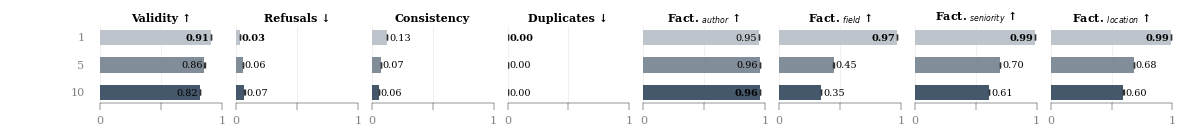

social
../../../results/plots/plot_social_k.pdf
Saved → ../../../results/plots/plot_social_k.pdf


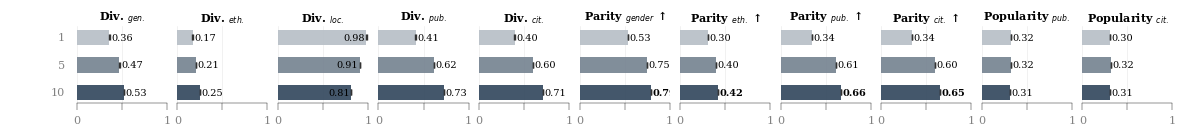

In [51]:
df_k = aggregate_scores(df_valid_calls, ['k'])
display(df_k)

for metric_type, metric_list in METRIC_TYPES.items():

    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_k.pdf')
    print(fn)
    plot_grouped_metrics(
        df_k,
        group_configs=[
            {'label': 'Top-k', 'column': 'k', 'color': '#34495E', 'order': K_ORDER},
        ],
        metrics=metric_list,
        metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=FIG_SIZE
    )

### K and Language

,k,language,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,factuality_mean,factuality_ci,factuality_std,factuality_field_mean,factuality_field_ci,...,pct_med_works_ci,pct_med_works_std,pct_high_works_mean,pct_high_works_ci,pct_high_works_std,pct_low_citations_mean,pct_low_citations_ci,pct_low_citations_std,pct_med_citations_mean,pct_med_citations_ci,pct_med_citations_std,pct_high_citations_mean,pct_high_citations_ci,pct_high_citations_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,1,English,103200,0.8851,0.0019,0.3189,0.0488,0.0013,0.2155,0.1095,0.0013,0.2071,0.0001,0.0001,0.0078,0.9539,0.0013,0.2042,0.9454,0.0026,...,0.0032,0.4611,0.3265,0.0032,0.4614,0.3493,0.0033,0.4695,0.3449,0.0032,0.4671,0.3059,0.0031,0.4533,0.3265,0.0032,0.4614,0.3059,0.0031,0.4533
1,1,German,103200,0.9007,0.0018,0.2990,0.0316,0.0011,0.1750,0.1295,0.0014,0.2247,0.0004,0.0001,0.0156,0.9530,0.0013,0.2086,0.9725,0.0018,...,0.0032,0.4636,0.3322,0.0032,0.4663,0.3385,0.0032,0.4689,0.3530,0.0033,0.4728,0.3085,0.0032,0.4579,0.3322,0.0032,0.4663,0.3085,0.0032,0.4579
2,1,Spanish,103200,0.9429,0.0014,0.2320,0.0128,0.0007,0.1123,0.1385,0.0015,0.2370,0.0002,0.0001,0.0117,0.9473,0.0014,0.2218,0.9816,0.0015,...,0.0031,0.4692,0.3097,0.0031,0.4597,0.3582,0.0032,0.4762,0.3476,0.0032,0.4732,0.2942,0.0030,0.4537,0.3097,0.0031,0.4597,0.2942,0.0030,0.4537
3,5,English,103200,0.8431,0.0022,0.3637,0.0734,0.0016,0.2607,0.0668,0.0008,0.1207,0.0012,0.0002,0.0265,0.9578,0.0009,0.1417,0.4407,0.0025,...,0.0019,0.2776,0.3289,0.0021,0.3049,0.3492,0.0023,0.3444,0.3276,0.0019,0.2820,0.3231,0.0021,0.3098,0.3289,0.0021,0.3049,0.3231,0.0021,0.3098
4,5,German,103200,0.8465,0.0022,0.3604,0.0589,0.0014,0.2355,0.0744,0.0008,0.1274,0.0015,0.0002,0.0311,0.9577,0.0010,0.1552,0.4618,0.0028,...,0.0020,0.2964,0.3274,0.0021,0.3167,0.3402,0.0024,0.3556,0.3377,0.0020,0.3017,0.3221,0.0022,0.3199,0.3274,0.0021,0.3167,0.3221,0.0022,0.3199
5,5,Spanish,103200,0.8783,0.0020,0.3269,0.0378,0.0012,0.1907,0.0767,0.0009,0.1332,0.0012,0.0002,0.0264,0.9541,0.0010,0.1560,0.4411,0.0025,...,0.0018,0.2794,0.3105,0.0020,0.2977,0.3570,0.0023,0.3451,0.3333,0.0018,0.2807,0.3097,0.0020,0.3041,0.3105,0.0020,0.2977,0.3097,0.0020,0.3041
6,10,English,103200,0.8079,0.0024,0.3939,0.0881,0.0017,0.2835,0.0545,0.0007,0.0967,0.0033,0.0003,0.0379,0.9583,0.0009,0.1309,0.3412,0.0022,...,0.0016,0.2357,0.3162,0.0018,0.2670,0.3534,0.0021,0.3132,0.3330,0.0016,0.2396,0.3136,0.0019,0.2724,0.3162,0.0018,0.2670,0.3136,0.0019,0.2724
7,10,German,103200,0.8078,0.0024,0.3941,0.0765,0.0016,0.2658,0.0574,0.0007,0.1017,0.0029,0.0003,0.0370,0.9576,0.0010,0.1463,0.3578,0.0025,...,0.0018,0.2618,0.3130,0.0020,0.2830,0.3488,0.0023,0.3282,0.3399,0.0018,0.2676,0.3113,0.0020,0.2871,0.3130,0.0020,0.2830,0.3113,0.0020,0.2871
8,10,Spanish,103200,0.8440,0.0022,0.3628,0.0460,0.0013,0.2094,0.0590,0.0007,0.1020,0.0030,0.0002,0.0362,0.9541,0.0010,0.1459,0.3402,0.0022,...,0.0016,0.2367,0.2970,0.0017,0.2572,0.3666,0.0021,0.3160,0.3347,0.0016,0.2380,0.2987,0.0018,0.2657,0.2970,0.0017,0.2572,0.2987,0.0018,0.2657


technical
../../../results/plots/plot_technical_k_lang.pdf
Saved → ../../../results/plots/plot_technical_k_lang.pdf


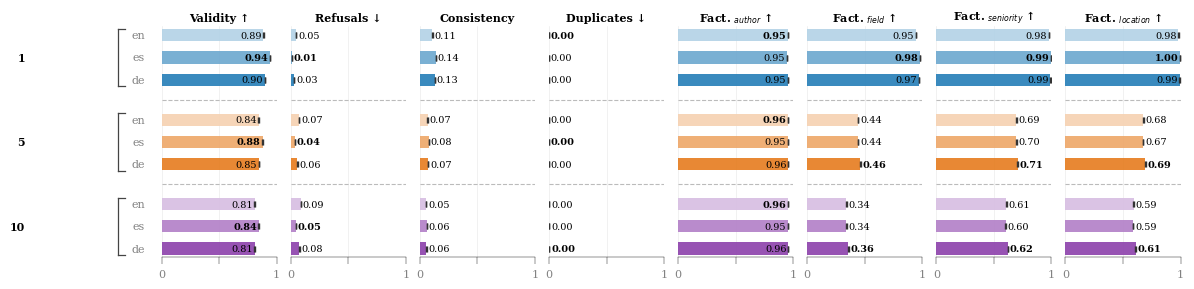

social
../../../results/plots/plot_social_k_lang.pdf
Saved → ../../../results/plots/plot_social_k_lang.pdf


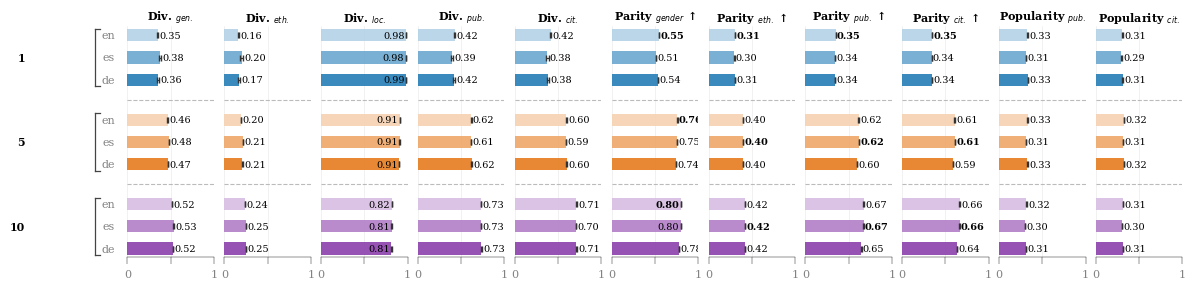

In [52]:

df_k_lang = aggregate_scores(df_valid_calls, ['k','language'])
display(df_k_lang)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_k_lang.pdf')
    print(fn)
    
    plot_grouped_metrics_labeled(
        df_k_lang,
        group_configs=[
            {'label': str(k), 'column': 'language', 'color': K_COLORS[k], 'filter': {'k': k}, 'order': LANGUAGE_ORDER} for k in K_ORDER
        ],
        row_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(LANGUAGE_ORDER))
    )


## Language

,language,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,factuality_mean,factuality_ci,factuality_std,factuality_field_mean,factuality_field_ci,factuality_field_std,...,pct_med_works_ci,pct_med_works_std,pct_high_works_mean,pct_high_works_ci,pct_high_works_std,pct_low_citations_mean,pct_low_citations_ci,pct_low_citations_std,pct_med_citations_mean,pct_med_citations_ci,pct_med_citations_std,pct_high_citations_mean,pct_high_citations_ci,pct_high_citations_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,English,309600,0.8454,0.0013,0.3615,0.0701,0.0009,0.2553,0.0778,0.0006,0.1528,0.0015,0.0001,0.0267,0.9566,0.0006,0.1634,0.4802,0.0020,0.3139,...,0.0013,0.3374,0.3239,0.0014,0.3531,0.3506,0.0015,0.3805,0.3350,0.0014,0.3423,0.3144,0.0014,0.3525,0.3239,0.0014,0.3531,0.3144,0.0014,0.3525
1,German,309600,0.8517,0.0013,0.3554,0.0557,0.0008,0.2293,0.0885,0.0006,0.1656,0.0016,0.0001,0.0289,0.9560,0.0007,0.1735,0.5041,0.0021,0.3266,...,0.0014,0.3513,0.3243,0.0014,0.3638,0.3425,0.0015,0.3887,0.3435,0.0014,0.3583,0.3141,0.0014,0.3622,0.3243,0.0014,0.3638,0.3141,0.0014,0.3622
2,Spanish,309600,0.8884,0.0011,0.3148,0.0322,0.0006,0.1765,0.0930,0.0006,0.1738,0.0014,0.0001,0.0263,0.9517,0.0007,0.1793,0.4832,0.0020,0.3165,...,0.0013,0.3429,0.3058,0.0013,0.3488,0.3605,0.0015,0.3850,0.3385,0.0013,0.3454,0.3010,0.0013,0.3502,0.3058,0.0013,0.3488,0.3010,0.0013,0.3502


technical
../../../results/plots/plot_technical_lang.pdf
Saved → ../../../results/plots/plot_technical_lang.pdf


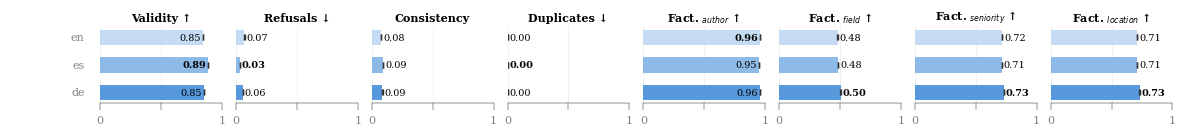

social
../../../results/plots/plot_social_lang.pdf
Saved → ../../../results/plots/plot_social_lang.pdf


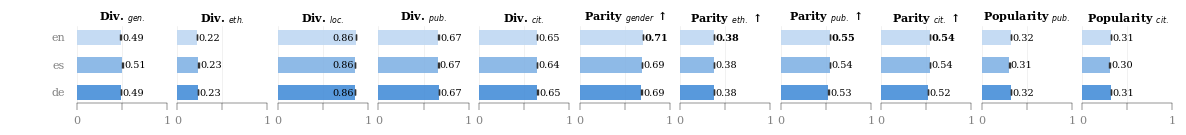

In [53]:

df_lang = aggregate_scores(df_valid_calls, ['language'])
display(df_lang)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_lang.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_lang,
        group_configs=[
            {'label': 'Language', 'column': 'language', 'color': '#4A90D9',
            'order': LANGUAGE_ORDER},
        ],
        row_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=FIG_SIZE
    )


### Language and K

,language,k,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,factuality_mean,factuality_ci,factuality_std,factuality_field_mean,factuality_field_ci,...,pct_med_works_ci,pct_med_works_std,pct_high_works_mean,pct_high_works_ci,pct_high_works_std,pct_low_citations_mean,pct_low_citations_ci,pct_low_citations_std,pct_med_citations_mean,pct_med_citations_ci,pct_med_citations_std,pct_high_citations_mean,pct_high_citations_ci,pct_high_citations_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,English,1,103200,0.8851,0.0019,0.3189,0.0488,0.0013,0.2155,0.1095,0.0013,0.2071,0.0001,0.0001,0.0078,0.9539,0.0013,0.2042,0.9454,0.0026,...,0.0032,0.4611,0.3265,0.0032,0.4614,0.3493,0.0033,0.4695,0.3449,0.0032,0.4671,0.3059,0.0031,0.4533,0.3265,0.0032,0.4614,0.3059,0.0031,0.4533
1,English,5,103200,0.8431,0.0022,0.3637,0.0734,0.0016,0.2607,0.0668,0.0008,0.1207,0.0012,0.0002,0.0265,0.9578,0.0009,0.1417,0.4407,0.0025,...,0.0019,0.2776,0.3289,0.0021,0.3049,0.3492,0.0023,0.3444,0.3276,0.0019,0.2820,0.3231,0.0021,0.3098,0.3289,0.0021,0.3049,0.3231,0.0021,0.3098
2,English,10,103200,0.8079,0.0024,0.3939,0.0881,0.0017,0.2835,0.0545,0.0007,0.0967,0.0033,0.0003,0.0379,0.9583,0.0009,0.1309,0.3412,0.0022,...,0.0016,0.2357,0.3162,0.0018,0.2670,0.3534,0.0021,0.3132,0.3330,0.0016,0.2396,0.3136,0.0019,0.2724,0.3162,0.0018,0.2670,0.3136,0.0019,0.2724
3,German,1,103200,0.9007,0.0018,0.2990,0.0316,0.0011,0.1750,0.1295,0.0014,0.2247,0.0004,0.0001,0.0156,0.9530,0.0013,0.2086,0.9725,0.0018,...,0.0032,0.4636,0.3322,0.0032,0.4663,0.3385,0.0032,0.4689,0.3530,0.0033,0.4728,0.3085,0.0032,0.4579,0.3322,0.0032,0.4663,0.3085,0.0032,0.4579
4,German,5,103200,0.8465,0.0022,0.3604,0.0589,0.0014,0.2355,0.0744,0.0008,0.1274,0.0015,0.0002,0.0311,0.9577,0.0010,0.1552,0.4618,0.0028,...,0.0020,0.2964,0.3274,0.0021,0.3167,0.3402,0.0024,0.3556,0.3377,0.0020,0.3017,0.3221,0.0022,0.3199,0.3274,0.0021,0.3167,0.3221,0.0022,0.3199
5,German,10,103200,0.8078,0.0024,0.3941,0.0765,0.0016,0.2658,0.0574,0.0007,0.1017,0.0029,0.0003,0.0370,0.9576,0.0010,0.1463,0.3578,0.0025,...,0.0018,0.2618,0.3130,0.0020,0.2830,0.3488,0.0023,0.3282,0.3399,0.0018,0.2676,0.3113,0.0020,0.2871,0.3130,0.0020,0.2830,0.3113,0.0020,0.2871
6,Spanish,1,103200,0.9429,0.0014,0.2320,0.0128,0.0007,0.1123,0.1385,0.0015,0.2370,0.0002,0.0001,0.0117,0.9473,0.0014,0.2218,0.9816,0.0015,...,0.0031,0.4692,0.3097,0.0031,0.4597,0.3582,0.0032,0.4762,0.3476,0.0032,0.4732,0.2942,0.0030,0.4537,0.3097,0.0031,0.4597,0.2942,0.0030,0.4537
7,Spanish,5,103200,0.8783,0.0020,0.3269,0.0378,0.0012,0.1907,0.0767,0.0009,0.1332,0.0012,0.0002,0.0264,0.9541,0.0010,0.1560,0.4411,0.0025,...,0.0018,0.2794,0.3105,0.0020,0.2977,0.3570,0.0023,0.3451,0.3333,0.0018,0.2807,0.3097,0.0020,0.3041,0.3105,0.0020,0.2977,0.3097,0.0020,0.3041
8,Spanish,10,103200,0.8440,0.0022,0.3628,0.0460,0.0013,0.2094,0.0590,0.0007,0.1020,0.0030,0.0002,0.0362,0.9541,0.0010,0.1459,0.3402,0.0022,...,0.0016,0.2367,0.2970,0.0017,0.2572,0.3666,0.0021,0.3160,0.3347,0.0016,0.2380,0.2987,0.0018,0.2657,0.2970,0.0017,0.2572,0.2987,0.0018,0.2657


technical
../../../results/plots/plot_technical_lang_k.pdf
Saved → ../../../results/plots/plot_technical_lang_k.pdf


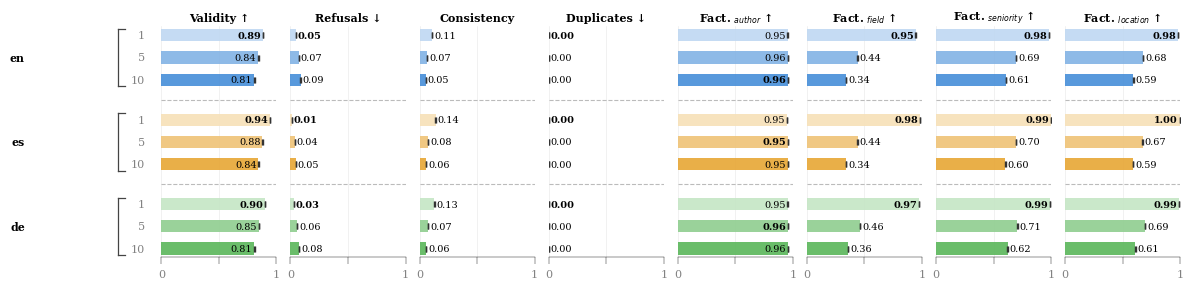

social
../../../results/plots/plot_social_lang_k.pdf
Saved → ../../../results/plots/plot_social_lang_k.pdf


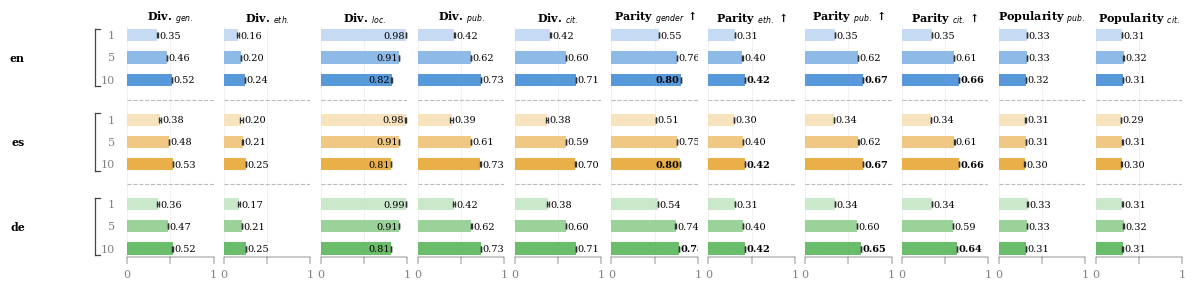

In [54]:
df_lang_k = aggregate_scores(df_valid_calls, ['language','k'])
display(df_lang_k)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_lang_k.pdf')
    print(fn)
    
    plot_grouped_metrics_labeled(
        df_lang_k,
        group_configs=[
            {'label': lang, 
             'column': 'k', 
             'color': LANGUAGE_COLORS[lang],
            'filter': {'language': lang}, 
            'order': K_ORDER} for lang in LANGUAGE_ORDER
        ],
        section_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(LANGUAGE_ORDER))
    )


### Language and Task

,language,task_en,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,factuality_mean,factuality_ci,factuality_std,factuality_field_mean,factuality_field_ci,...,pct_med_works_ci,pct_med_works_std,pct_high_works_mean,pct_high_works_ci,pct_high_works_std,pct_low_citations_mean,pct_low_citations_ci,pct_low_citations_std,pct_med_citations_mean,pct_med_citations_ci,pct_med_citations_std,pct_high_citations_mean,pct_high_citations_ci,pct_high_citations_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,English,seeking an advisor,154800,0.8391,0.0018,0.3675,0.0678,0.0013,0.2514,0.0712,0.0008,0.1467,0.0016,0.0001,0.0272,0.9526,0.0009,0.1707,0.4777,0.0028,...,0.0019,0.3370,0.3195,0.0020,0.3527,0.3619,0.0021,0.3817,0.3289,0.0019,0.3407,0.3092,0.0020,0.3516,0.3195,0.0020,0.3527,0.3092,0.0020,0.3516
1,English,seeking potential hires,154800,0.8517,0.0018,0.3554,0.0724,0.0013,0.2592,0.0843,0.0009,0.1584,0.0014,0.0001,0.0263,0.9605,0.0008,0.1557,0.4827,0.0028,...,0.0019,0.3378,0.3282,0.0020,0.3533,0.3397,0.0021,0.3790,0.3409,0.0019,0.3436,0.3194,0.0020,0.3533,0.3282,0.0020,0.3533,0.3194,0.0020,0.3533
2,German,seeking an advisor,154800,0.8475,0.0018,0.3595,0.0558,0.0011,0.2296,0.0757,0.0008,0.1518,0.0017,0.0002,0.0306,0.9526,0.0010,0.1806,0.5000,0.0030,...,0.0020,0.3474,0.3233,0.0020,0.3616,0.3518,0.0022,0.3885,0.3349,0.0020,0.3527,0.3134,0.0020,0.3600,0.3233,0.0020,0.3616,0.3134,0.0020,0.3600
3,German,seeking potential hires,154800,0.8559,0.0017,0.3512,0.0555,0.0011,0.2290,0.1012,0.0010,0.1773,0.0014,0.0001,0.0272,0.9594,0.0009,0.1661,0.5084,0.0030,...,0.0020,0.3549,0.3252,0.0020,0.3659,0.3334,0.0022,0.3886,0.3518,0.0020,0.3634,0.3147,0.0020,0.3643,0.3252,0.0020,0.3659,0.3147,0.0020,0.3643
4,Spanish,seeking an advisor,154800,0.8866,0.0016,0.3171,0.0276,0.0008,0.1639,0.0842,0.0009,0.1655,0.0016,0.0001,0.0281,0.9483,0.0010,0.1845,0.4810,0.0028,...,0.0019,0.3424,0.3018,0.0019,0.3465,0.3687,0.0021,0.3845,0.3349,0.0019,0.3436,0.2964,0.0019,0.3471,0.3018,0.0019,0.3465,0.2964,0.0019,0.3471
5,Spanish,seeking potential hires,154800,0.8903,0.0016,0.3125,0.0367,0.0009,0.1881,0.1017,0.0010,0.1813,0.0013,0.0001,0.0245,0.9551,0.0009,0.1740,0.4854,0.0028,...,0.0019,0.3434,0.3097,0.0019,0.3510,0.3526,0.0021,0.3853,0.3420,0.0019,0.3470,0.3054,0.0019,0.3531,0.3097,0.0019,0.3510,0.3054,0.0019,0.3531


technical
../../../results/plots/plot_technical_task_lang.pdf
Saved → ../../../results/plots/plot_technical_task_lang.pdf


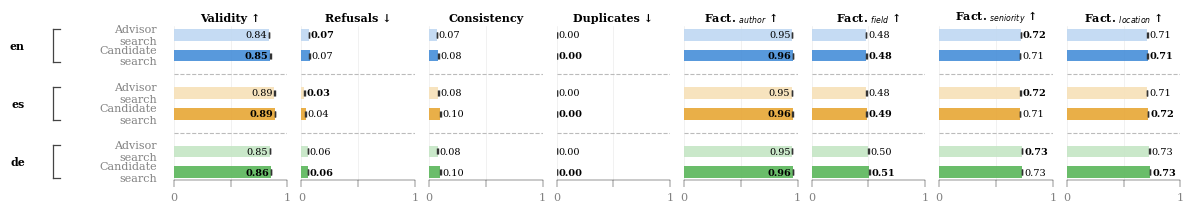

social
../../../results/plots/plot_social_task_lang.pdf
Saved → ../../../results/plots/plot_social_task_lang.pdf


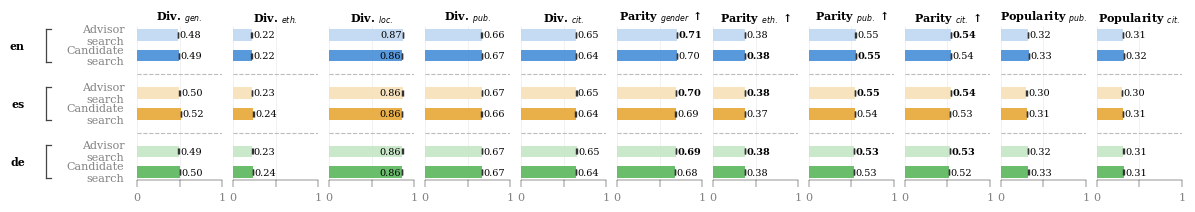

In [55]:

df_lang_task = aggregate_scores(df_valid_calls, ['language','task_en'])
display(df_lang_task)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_task_lang.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_lang_task,
        group_configs=[
            {'label': language, 'column': 'task_en', 'color': LANGUAGE_COLORS[language],
            'filter': {'language': language}, 
            'order': TASK_ORDER}
            for language in LANGUAGE_ORDER
        ],
        section_labels=LANGUAGE_MAP,
        row_labels=TASK_MAP,
        metrics=metric_list,
        metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(TASK_ORDER))
    )


## Location

,location,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,factuality_mean,factuality_ci,factuality_std,factuality_field_mean,factuality_field_ci,factuality_field_std,...,pct_med_works_ci,pct_med_works_std,pct_high_works_mean,pct_high_works_ci,pct_high_works_std,pct_low_citations_mean,pct_low_citations_ci,pct_low_citations_std,pct_med_citations_mean,pct_med_citations_ci,pct_med_citations_std,pct_high_citations_mean,pct_high_citations_ci,pct_high_citations_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,Canada,185760,0.8634,0.0016,0.3435,0.0503,0.0010,0.2186,0.1203,0.0009,0.1895,0.0014,0.0001,0.0254,0.9764,0.0006,0.1235,0.4643,0.0024,0.3130,...,0.0018,0.3509,0.3536,0.0018,0.3566,0.2598,0.0017,0.3395,0.3440,0.0017,0.3493,0.3962,0.0019,0.3751,0.3536,0.0018,0.3566,0.3962,0.0019,0.3751
1,Ecuador,185760,0.8522,0.0016,0.3549,0.0608,0.0011,0.2390,0.0593,0.0007,0.1350,0.0011,0.0001,0.0242,0.9841,0.0005,0.1095,0.5093,0.0028,0.3195,...,0.0018,0.3584,0.2029,0.0015,0.2934,0.4126,0.0021,0.4115,0.3682,0.0018,0.3565,0.2192,0.0015,0.3070,0.2029,0.0015,0.2934,0.2192,0.0015,0.3070
2,Germany,185760,0.8638,0.0016,0.3431,0.0486,0.0010,0.2150,0.0907,0.0008,0.1678,0.0016,0.0001,0.0296,0.9643,0.0007,0.1532,0.4698,0.0024,0.3145,...,0.0017,0.3366,0.3311,0.0018,0.3516,0.3295,0.0019,0.3668,0.3573,0.0018,0.3511,0.3132,0.0018,0.3489,0.3311,0.0018,0.3516,0.3132,0.0018,0.3489
3,Japan,185760,0.8739,0.0015,0.3320,0.0496,0.0010,0.2172,0.0868,0.0008,0.1656,0.0016,0.0001,0.0281,0.9880,0.0005,0.0966,0.5280,0.0028,0.3315,...,0.0016,0.3152,0.5051,0.0018,0.3666,0.2381,0.0016,0.3164,0.3419,0.0017,0.3401,0.4200,0.0018,0.3638,0.5051,0.0018,0.3666,0.4200,0.0018,0.3638
4,South Africa,185760,0.8559,0.0016,0.3512,0.0539,0.0010,0.2259,0.0751,0.0008,0.1536,0.0018,0.0001,0.0291,0.8600,0.0014,0.2783,0.4807,0.0027,0.3128,...,0.0018,0.3435,0.1778,0.0016,0.2952,0.5371,0.0021,0.4085,0.2783,0.0018,0.3388,0.1845,0.0016,0.3086,0.1778,0.0016,0.2952,0.1845,0.0016,0.3086


technical
../../../results/plots/plot_technical_loc.pdf
Saved → ../../../results/plots/plot_technical_loc.pdf


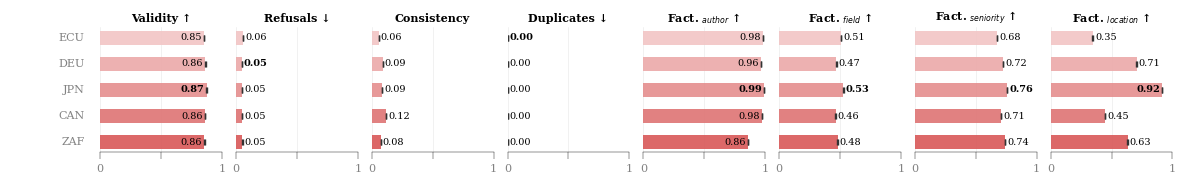

social
../../../results/plots/plot_social_loc.pdf
Saved → ../../../results/plots/plot_social_loc.pdf


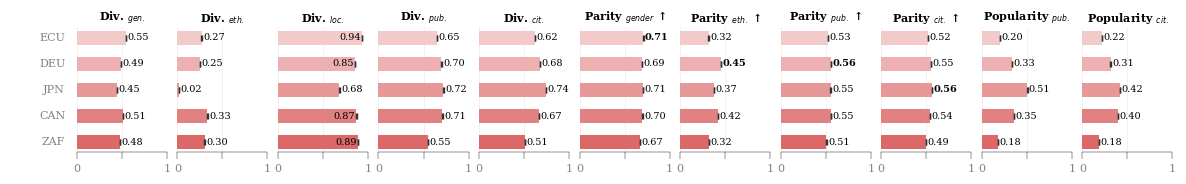

In [56]:

df_loc = aggregate_scores(df_valid_calls, ['location'])
display(df_loc)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_loc.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_loc,
        group_configs=[
            {'label': 'Location', 'column': 'location', 'color': '#D95B5B',
            'order': LOCATION_ORDER},
        ],
        metrics=metric_list,
        metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
        row_labels=LOCATION_MAP,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT + (len(LOCATION_ORDER)/8))
    )


### Location and Language

,location,language,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,factuality_mean,factuality_ci,factuality_std,factuality_field_mean,factuality_field_ci,...,pct_med_works_ci,pct_med_works_std,pct_high_works_mean,pct_high_works_ci,pct_high_works_std,pct_low_citations_mean,pct_low_citations_ci,pct_low_citations_std,pct_med_citations_mean,pct_med_citations_ci,pct_med_citations_std,pct_high_citations_mean,pct_high_citations_ci,pct_high_citations_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,Canada,English,61920,0.8480,0.0028,0.3590,0.0709,0.0020,0.2566,0.1099,0.0015,0.1769,0.0015,0.0002,0.0260,0.9762,0.0010,0.1174,0.4574,0.0041,...,0.0030,0.3435,0.3615,0.0031,0.3533,0.2572,0.0029,0.3342,0.3394,0.0030,0.3426,0.4033,0.0032,0.3714,0.3615,0.0031,0.3533,0.4033,0.0032,0.3714
1,Canada,German,61920,0.8543,0.0028,0.3528,0.0504,0.0017,0.2187,0.1274,0.0016,0.1931,0.0014,0.0002,0.0263,0.9761,0.0011,0.1300,0.4767,0.0044,...,0.0031,0.3605,0.3597,0.0032,0.3640,0.2467,0.0030,0.3390,0.3506,0.0031,0.3597,0.4027,0.0033,0.3822,0.3597,0.0032,0.3640,0.4027,0.0033,0.3822
2,Canada,Spanish,61920,0.8878,0.0025,0.3156,0.0297,0.0013,0.1697,0.1235,0.0016,0.1970,0.0013,0.0002,0.0239,0.9768,0.0010,0.1229,0.4597,0.0041,...,0.0030,0.3485,0.3404,0.0030,0.3524,0.2748,0.0029,0.3444,0.3422,0.0029,0.3456,0.3830,0.0032,0.3713,0.3404,0.0030,0.3524,0.3830,0.0032,0.3713
3,Ecuador,English,61920,0.8345,0.0029,0.3716,0.0810,0.0021,0.2728,0.0483,0.0010,0.1202,0.0008,0.0002,0.0197,0.9878,0.0008,0.0903,0.4980,0.0047,...,0.0031,0.3496,0.2002,0.0025,0.2846,0.4240,0.0036,0.4065,0.3604,0.0030,0.3468,0.2156,0.0026,0.2985,0.2002,0.0025,0.2846,0.2156,0.0026,0.2985
4,Ecuador,German,61920,0.8419,0.0029,0.3648,0.0640,0.0019,0.2448,0.0615,0.0012,0.1356,0.0013,0.0002,0.0282,0.9828,0.0010,0.1171,0.5262,0.0050,...,0.0032,0.3665,0.2154,0.0027,0.3095,0.4003,0.0037,0.4168,0.3775,0.0032,0.3679,0.2222,0.0028,0.3147,0.2154,0.0027,0.3095,0.2222,0.0028,0.3147
5,Ecuador,Spanish,61920,0.8803,0.0026,0.3247,0.0375,0.0015,0.1899,0.0675,0.0012,0.1465,0.0011,0.0002,0.0239,0.9818,0.0010,0.1182,0.5049,0.0046,...,0.0031,0.3589,0.1936,0.0024,0.2854,0.4133,0.0035,0.4108,0.3668,0.0030,0.3543,0.2199,0.0026,0.3074,0.1936,0.0024,0.2854,0.2199,0.0026,0.3074
6,Germany,English,61920,0.8491,0.0028,0.3579,0.0646,0.0019,0.2457,0.0847,0.0014,0.1590,0.0017,0.0003,0.0303,0.9696,0.0011,0.1338,0.4638,0.0041,...,0.0030,0.3336,0.3422,0.0031,0.3513,0.3231,0.0032,0.3575,0.3560,0.0031,0.3462,0.3209,0.0031,0.3485,0.3422,0.0031,0.3513,0.3209,0.0031,0.3485
7,Germany,German,61920,0.8483,0.0028,0.3588,0.0528,0.0018,0.2236,0.0917,0.0014,0.1670,0.0019,0.0003,0.0321,0.9570,0.0015,0.1723,0.4864,0.0045,...,0.0030,0.3381,0.3277,0.0032,0.3569,0.3351,0.0034,0.3782,0.3579,0.0032,0.3594,0.3070,0.0032,0.3511,0.3277,0.0032,0.3569,0.3070,0.0032,0.3511
8,Germany,Spanish,61920,0.8939,0.0024,0.3080,0.0284,0.0013,0.1662,0.0954,0.0015,0.1762,0.0013,0.0002,0.0263,0.9660,0.0013,0.1510,0.4606,0.0041,...,0.0029,0.3377,0.3238,0.0030,0.3468,0.3305,0.0031,0.3646,0.3580,0.0030,0.3482,0.3115,0.0030,0.3473,0.3238,0.0030,0.3468,0.3115,0.0030,0.3473
9,Japan,English,61920,0.8555,0.0028,0.3516,0.0653,0.0019,0.2470,0.0748,0.0012,0.1442,0.0018,0.0003,0.0294,0.9923,0.0006,0.0724,0.5176,0.0047,...,0.0027,0.3106,0.5103,0.0031,0.3612,0.2349,0.0027,0.3100,0.3420,0.0029,0.3360,0.4231,0.0031,0.3589,0.5103,0.0031,0.3612,0.4231,0.0031,0.3589


technical
../../../results/plots/plot_technical_loc_lang.pdf
Saved → ../../../results/plots/plot_technical_loc_lang.pdf


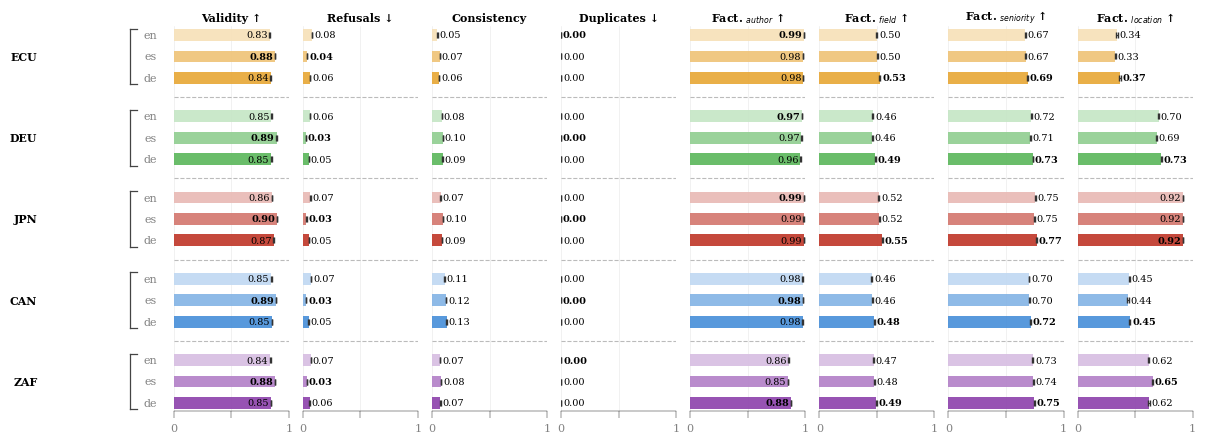

social
../../../results/plots/plot_social_loc_lang.pdf
Saved → ../../../results/plots/plot_social_loc_lang.pdf


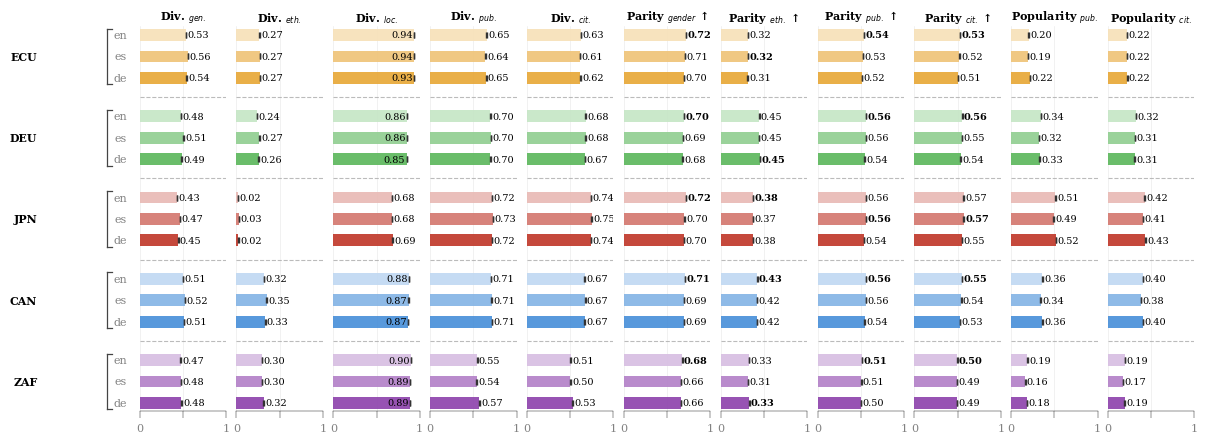

In [57]:

df_loc_lang = aggregate_scores(df_valid_calls, ['location','language'])
display(df_loc_lang)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_loc_lang.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_loc_lang,
        group_configs=[
            {'label': loc, 'column': 'language', 'color': LOCATION_COLORS[loc],
            'filter': {'location': loc}, 'order': LANGUAGE_ORDER} for loc in LOCATION_ORDER
        ],
        section_labels=LOCATION_MAP,
        row_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(LOCATION_ORDER))   
    );


## Task

,task_en,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,factuality_mean,factuality_ci,factuality_std,factuality_field_mean,factuality_field_ci,factuality_field_std,...,pct_med_works_ci,pct_med_works_std,pct_high_works_mean,pct_high_works_ci,pct_high_works_std,pct_low_citations_mean,pct_low_citations_ci,pct_low_citations_std,pct_med_citations_mean,pct_med_citations_ci,pct_med_citations_std,pct_high_citations_mean,pct_high_citations_ci,pct_high_citations_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,seeking an advisor,464400,0.8577,0.0010,0.3494,0.0504,0.0006,0.2188,0.0771,0.0005,0.1552,0.0016,0.0001,0.0287,0.9511,0.0006,0.1788,0.4860,0.0016,0.3183,...,0.0011,0.3423,0.3146,0.0011,0.3536,0.3609,0.0012,0.3850,0.3329,0.0011,0.3457,0.3061,0.0011,0.3529,0.3146,0.0011,0.3536,0.3061,0.0011,0.3529
1,seeking potential hires,464400,0.8660,0.0010,0.3407,0.0549,0.0007,0.2278,0.0958,0.0005,0.1729,0.0014,0.0001,0.0260,0.9583,0.0005,0.1656,0.4917,0.0017,0.3197,...,0.0011,0.3454,0.3209,0.0011,0.3568,0.3421,0.0012,0.3844,0.3449,0.0011,0.3514,0.3130,0.0011,0.3569,0.3209,0.0011,0.3568,0.3130,0.0011,0.3569


technical
../../../results/plots/plot_technical_task.pdf
Saved → ../../../results/plots/plot_technical_task.pdf


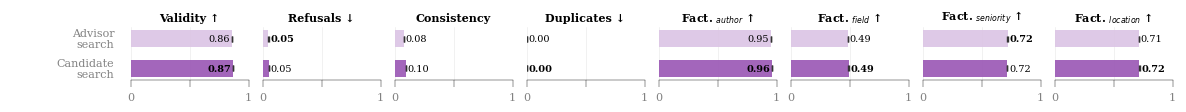

social
../../../results/plots/plot_social_task.pdf
Saved → ../../../results/plots/plot_social_task.pdf


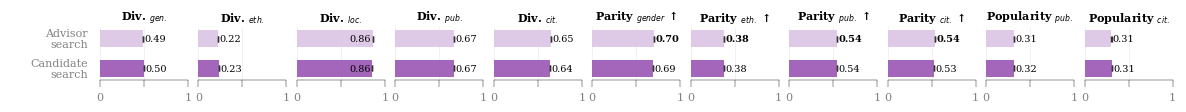

In [58]:

df_task = aggregate_scores(df_valid_calls, ['task_en'])
display(df_task)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_task.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_task,
        group_configs=[
            {'label': 'Task', 'column': 'task_en', 'color': '#9B59B6',
            'order': ['seeking an advisor', 'seeking potential hires']},
        ],
        row_labels=TASK_MAP,
        metrics=metric_list,
        metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * 0.7)
    )


### Task and K

,task_en,k,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,factuality_mean,factuality_ci,factuality_std,factuality_field_mean,factuality_field_ci,...,pct_med_works_ci,pct_med_works_std,pct_high_works_mean,pct_high_works_ci,pct_high_works_std,pct_low_citations_mean,pct_low_citations_ci,pct_low_citations_std,pct_med_citations_mean,pct_med_citations_ci,pct_med_citations_std,pct_high_citations_mean,pct_high_citations_ci,pct_high_citations_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,seeking an advisor,1,154800,0.9087,0.0014,0.2881,0.0299,0.0008,0.1703,0.1116,0.0011,0.2140,0.0003,0.0001,0.0132,0.9467,0.0012,0.2208,0.9657,0.0017,...,0.0026,0.4634,0.3177,0.0026,0.4610,0.3632,0.0027,0.4762,0.3366,0.0026,0.4676,0.3002,0.0026,0.4541,0.3177,0.0026,0.4610,0.3002,0.0026,0.4541
1,seeking an advisor,5,154800,0.8502,0.0018,0.3569,0.0553,0.0011,0.2285,0.0645,0.0006,0.1171,0.0016,0.0002,0.0305,0.9532,0.0008,0.1562,0.4435,0.0021,...,0.0016,0.2845,0.3182,0.0017,0.3055,0.3575,0.0019,0.3467,0.3295,0.0016,0.2873,0.3130,0.0017,0.3091,0.3182,0.0017,0.3055,0.3130,0.0017,0.3091
2,seeking an advisor,10,154800,0.8142,0.0019,0.3889,0.0660,0.0012,0.2483,0.0518,0.0005,0.0921,0.0032,0.0002,0.0378,0.9537,0.0008,0.1453,0.3443,0.0018,...,0.0014,0.2424,0.3077,0.0015,0.2680,0.3622,0.0018,0.3162,0.3329,0.0014,0.2455,0.3048,0.0015,0.2725,0.3077,0.0015,0.2680,0.3048,0.0015,0.2725
3,seeking potential hires,1,154800,0.9105,0.0014,0.2855,0.0322,0.0009,0.1766,0.1406,0.0012,0.2324,0.0002,0.0001,0.0109,0.9559,0.0011,0.2025,0.9671,0.0016,...,0.0026,0.4661,0.3272,0.0026,0.4640,0.3350,0.0026,0.4670,0.3600,0.0026,0.4742,0.3051,0.0025,0.4558,0.3272,0.0026,0.4640,0.3051,0.0025,0.4558
4,seeking potential hires,5,154800,0.8617,0.0017,0.3452,0.0581,0.0012,0.2340,0.0807,0.0007,0.1363,0.0011,0.0001,0.0254,0.9598,0.0008,0.1460,0.4517,0.0022,...,0.0015,0.2845,0.3258,0.0017,0.3074,0.3406,0.0019,0.3499,0.3362,0.0016,0.2889,0.3232,0.0017,0.3133,0.3258,0.0017,0.3074,0.3232,0.0017,0.3133
5,seeking potential hires,10,154800,0.8256,0.0019,0.3794,0.0743,0.0013,0.2623,0.0621,0.0006,0.1074,0.0029,0.0002,0.0363,0.9594,0.0008,0.1371,0.3479,0.0019,...,0.0014,0.2472,0.3094,0.0015,0.2703,0.3508,0.0018,0.3220,0.3387,0.0014,0.2515,0.3105,0.0015,0.2776,0.3094,0.0015,0.2703,0.3105,0.0015,0.2776


technical
../../../results/plots/plot_technical_task_k.pdf
Saved → ../../../results/plots/plot_technical_task_k.pdf


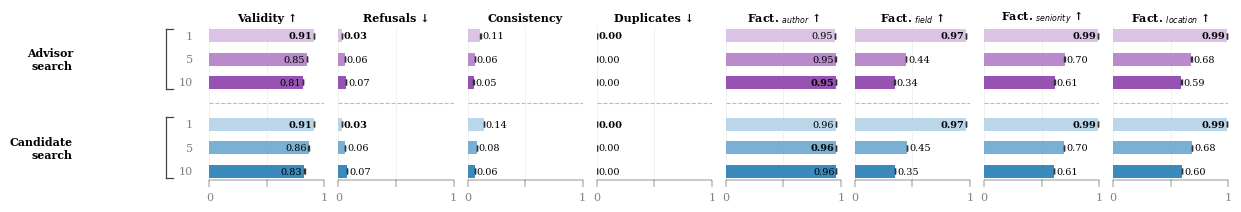

social
../../../results/plots/plot_social_task_k.pdf
Saved → ../../../results/plots/plot_social_task_k.pdf


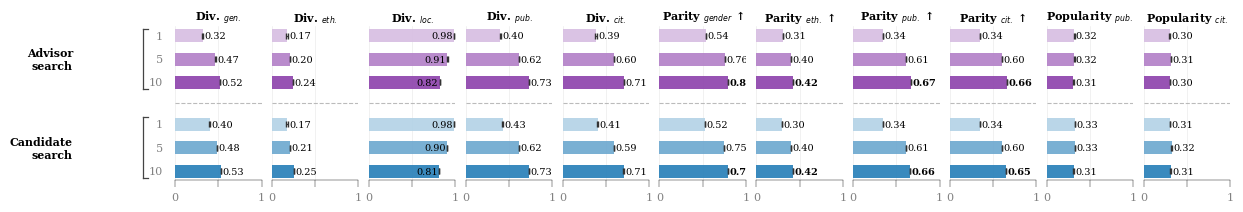

In [59]:

df_task_k = aggregate_scores(df_valid_calls, ['task_en','k'])
display(df_task_k)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_task_k.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_task_k,
        group_configs=[
            {'label': task_val, 'column': 'k', 'color': TASK_COLORS[task_val],
            'filter': {'task_en': task_val}, 'order': K_ORDER} for task_val in TASK_ORDER
        ],
        section_labels=TASK_MAP,
        metrics=metric_list,
        metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(TASK_ORDER))
    )


## Role

,role_en,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,factuality_mean,factuality_ci,factuality_std,factuality_field_mean,factuality_field_ci,factuality_field_std,...,pct_med_works_ci,pct_med_works_std,pct_high_works_mean,pct_high_works_ci,pct_high_works_std,pct_low_citations_mean,pct_low_citations_ci,pct_low_citations_std,pct_med_citations_mean,pct_med_citations_ci,pct_med_citations_std,pct_high_citations_mean,pct_high_citations_ci,pct_high_citations_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,Director/Recruiter,464400,0.8660,0.0010,0.3407,0.0549,0.0007,0.2278,0.0958,0.0005,0.1729,0.0014,0.0001,0.0260,0.9583,0.0005,0.1656,0.4917,0.0017,0.3197,...,0.0011,0.3454,0.3209,0.0011,0.3568,0.3421,0.0012,0.3844,0.3449,0.0011,0.3514,0.3130,0.0011,0.3569,0.3209,0.0011,0.3568,0.3130,0.0011,0.3569
1,PhD student,464400,0.8577,0.0010,0.3494,0.0504,0.0006,0.2188,0.0771,0.0005,0.1552,0.0016,0.0001,0.0287,0.9511,0.0006,0.1788,0.4860,0.0016,0.3183,...,0.0011,0.3423,0.3146,0.0011,0.3536,0.3609,0.0012,0.3850,0.3329,0.0011,0.3457,0.3061,0.0011,0.3529,0.3146,0.0011,0.3536,0.3061,0.0011,0.3529


technical
../../../results/plots/plot_technical_role.pdf
Saved → ../../../results/plots/plot_technical_role.pdf


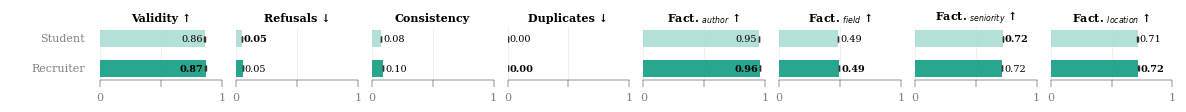

social
../../../results/plots/plot_social_role.pdf
Saved → ../../../results/plots/plot_social_role.pdf


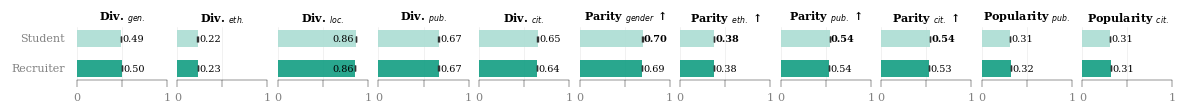

In [60]:

df_role = aggregate_scores(df_valid_calls, ['role_en'])
display(df_role)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_role.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_role,
        group_configs=[
            {'label': 'Role', 'column': 'role_en', 'color': '#16A085',
            'order': ROLE_ORDER},
        ],
        row_labels=ROLE_MAP,
        metrics=metric_list,
        metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * 0.7)
    )

### Role and Language

,role_en,language,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,factuality_mean,factuality_ci,factuality_std,factuality_field_mean,factuality_field_ci,...,pct_med_works_ci,pct_med_works_std,pct_high_works_mean,pct_high_works_ci,pct_high_works_std,pct_low_citations_mean,pct_low_citations_ci,pct_low_citations_std,pct_med_citations_mean,pct_med_citations_ci,pct_med_citations_std,pct_high_citations_mean,pct_high_citations_ci,pct_high_citations_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,Director/Recruiter,English,154800,0.8517,0.0018,0.3554,0.0724,0.0013,0.2592,0.0843,0.0009,0.1584,0.0014,0.0001,0.0263,0.9605,0.0008,0.1557,0.4827,0.0028,...,0.0019,0.3378,0.3282,0.0020,0.3533,0.3397,0.0021,0.3790,0.3409,0.0019,0.3436,0.3194,0.0020,0.3533,0.3282,0.0020,0.3533,0.3194,0.0020,0.3533
1,Director/Recruiter,German,154800,0.8559,0.0017,0.3512,0.0555,0.0011,0.2290,0.1012,0.0010,0.1773,0.0014,0.0001,0.0272,0.9594,0.0009,0.1661,0.5084,0.0030,...,0.0020,0.3549,0.3252,0.0020,0.3659,0.3334,0.0022,0.3886,0.3518,0.0020,0.3634,0.3147,0.0020,0.3643,0.3252,0.0020,0.3659,0.3147,0.0020,0.3643
2,Director/Recruiter,Spanish,154800,0.8903,0.0016,0.3125,0.0367,0.0009,0.1881,0.1017,0.0010,0.1813,0.0013,0.0001,0.0245,0.9551,0.0009,0.1740,0.4854,0.0028,...,0.0019,0.3434,0.3097,0.0019,0.3510,0.3526,0.0021,0.3853,0.3420,0.0019,0.3470,0.3054,0.0019,0.3531,0.3097,0.0019,0.3510,0.3054,0.0019,0.3531
3,PhD student,English,154800,0.8391,0.0018,0.3675,0.0678,0.0013,0.2514,0.0712,0.0008,0.1467,0.0016,0.0001,0.0272,0.9526,0.0009,0.1707,0.4777,0.0028,...,0.0019,0.3370,0.3195,0.0020,0.3527,0.3619,0.0021,0.3817,0.3289,0.0019,0.3407,0.3092,0.0020,0.3516,0.3195,0.0020,0.3527,0.3092,0.0020,0.3516
4,PhD student,German,154800,0.8475,0.0018,0.3595,0.0558,0.0011,0.2296,0.0757,0.0008,0.1518,0.0017,0.0002,0.0306,0.9526,0.0010,0.1806,0.5000,0.0030,...,0.0020,0.3474,0.3233,0.0020,0.3616,0.3518,0.0022,0.3885,0.3349,0.0020,0.3527,0.3134,0.0020,0.3600,0.3233,0.0020,0.3616,0.3134,0.0020,0.3600
5,PhD student,Spanish,154800,0.8866,0.0016,0.3171,0.0276,0.0008,0.1639,0.0842,0.0009,0.1655,0.0016,0.0001,0.0281,0.9483,0.0010,0.1845,0.4810,0.0028,...,0.0019,0.3424,0.3018,0.0019,0.3465,0.3687,0.0021,0.3845,0.3349,0.0019,0.3436,0.2964,0.0019,0.3471,0.3018,0.0019,0.3465,0.2964,0.0019,0.3471


technical
../../../results/plots/plot_technical_role_lang.pdf
Saved → ../../../results/plots/plot_technical_role_lang.pdf


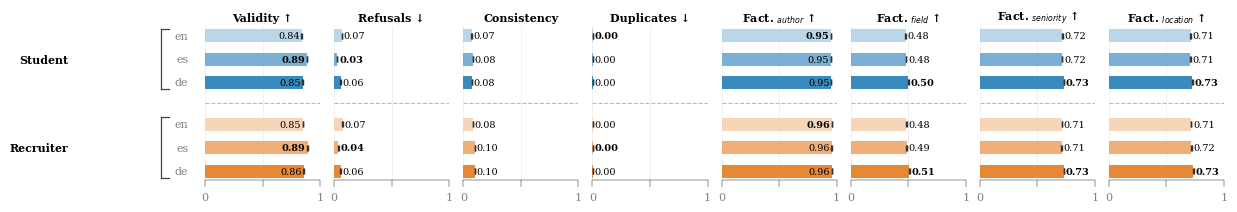

social
../../../results/plots/plot_social_role_lang.pdf
Saved → ../../../results/plots/plot_social_role_lang.pdf


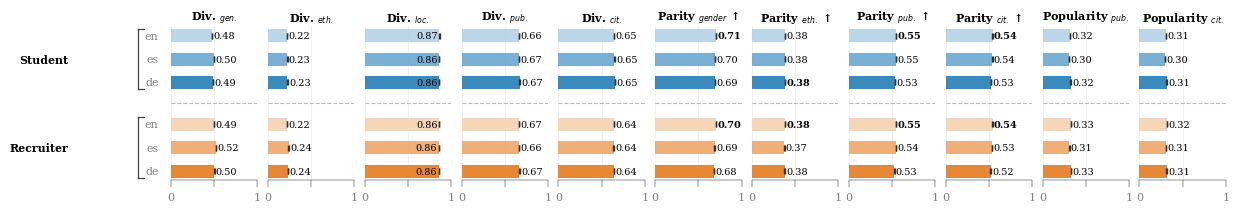

In [61]:

df_role_lang = aggregate_scores(df_valid_calls, ['role_en', 'language'])
display(df_role_lang)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_role_lang.pdf')
    print(fn)
        
    plot_grouped_metrics_labeled(
        df_role_lang,
        group_configs=[
            {'label': role_val, 'column': 'language', 'color': ROLE_COLORS[role_val],
            'filter': {'role_en': role_val}, 'order': LANGUAGE_ORDER}
            for role_val in ['PhD student', 'Director/Recruiter']
        ],
        section_labels=ROLE_MAP,
        row_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(ROLE_ORDER))
    )

## Field

,field_en,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,factuality_mean,factuality_ci,factuality_std,factuality_field_mean,factuality_field_ci,factuality_field_std,...,pct_med_works_ci,pct_med_works_std,pct_high_works_mean,pct_high_works_ci,pct_high_works_std,pct_low_citations_mean,pct_low_citations_ci,pct_low_citations_std,pct_med_citations_mean,pct_med_citations_ci,pct_med_citations_std,pct_high_citations_mean,pct_high_citations_ci,pct_high_citations_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,Biology,154800,0.8623,0.0017,0.3446,0.0536,0.0011,0.2251,0.0783,0.0008,0.1530,0.0011,0.0001,0.0233,0.9596,0.0009,0.1635,0.6161,0.0018,0.2831,...,0.0019,0.3416,0.3199,0.0020,0.3551,0.3525,0.0021,0.3864,0.3418,0.0019,0.3509,0.3057,0.0019,0.3518,0.3199,0.0020,0.3551,0.3057,0.0019,0.3518
1,Computer Science,154800,0.8695,0.0017,0.3368,0.0495,0.0011,0.2169,0.1111,0.0010,0.1912,0.0019,0.0002,0.0295,0.9581,0.0009,0.1654,0.3018,0.0029,0.2744,...,0.0019,0.3496,0.3251,0.0020,0.3690,0.3430,0.0021,0.3819,0.3420,0.0019,0.3535,0.3150,0.0020,0.3636,0.3251,0.0020,0.3690,0.3150,0.0020,0.3636
2,Mathematics,154800,0.8544,0.0018,0.3528,0.0547,0.0011,0.2273,0.0948,0.0009,0.1714,0.0017,0.0002,0.0290,0.9602,0.0009,0.1615,0.2875,0.0041,0.2756,...,0.0019,0.3456,0.3157,0.0019,0.3467,0.3475,0.0021,0.3815,0.3400,0.0019,0.3500,0.3125,0.0020,0.3517,0.3157,0.0019,0.3467,0.3125,0.0020,0.3517
3,Physics,154800,0.8599,0.0017,0.3471,0.0529,0.0011,0.2239,0.0817,0.0009,0.1631,0.0012,0.0001,0.0239,0.9503,0.0010,0.1805,0.3222,0.0035,0.3017,...,0.0019,0.3454,0.3185,0.0020,0.3564,0.3522,0.0021,0.3845,0.3394,0.0019,0.3489,0.3084,0.0020,0.3537,0.3185,0.0020,0.3564,0.3084,0.0020,0.3537
4,Psychology,154800,0.8630,0.0017,0.3438,0.0519,0.0011,0.2219,0.0767,0.0008,0.1531,0.0017,0.0002,0.0304,0.9518,0.0010,0.1775,0.3163,0.0036,0.2852,...,0.0019,0.3396,0.3152,0.0020,0.3524,0.3570,0.0022,0.3873,0.3365,0.0019,0.3453,0.3066,0.0020,0.3537,0.3152,0.0020,0.3524,0.3066,0.0020,0.3537
5,Sociology,154800,0.8619,0.0017,0.3450,0.0534,0.0011,0.2248,0.0765,0.0008,0.1489,0.0014,0.0001,0.0271,0.9483,0.0010,0.1838,0.5665,0.0020,0.2955,...,0.0019,0.3414,0.3120,0.0019,0.3510,0.3563,0.0021,0.3869,0.3341,0.0019,0.3431,0.3096,0.0020,0.3547,0.3120,0.0019,0.3510,0.3096,0.0020,0.3547


technical
../../../results/plots/plot_technical_field.pdf
Saved → ../../../results/plots/plot_technical_field.pdf


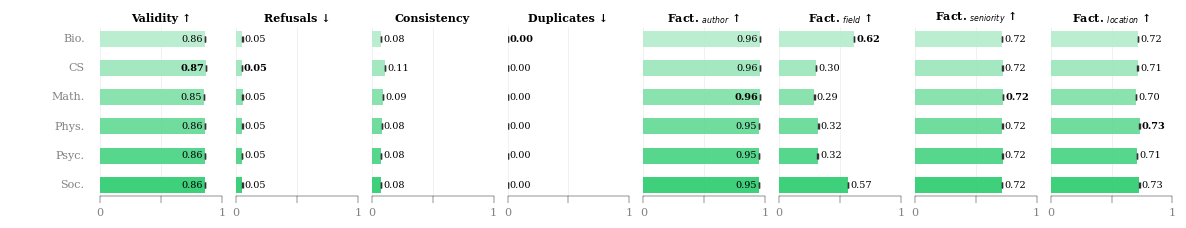

social
../../../results/plots/plot_social_field.pdf
Saved → ../../../results/plots/plot_social_field.pdf


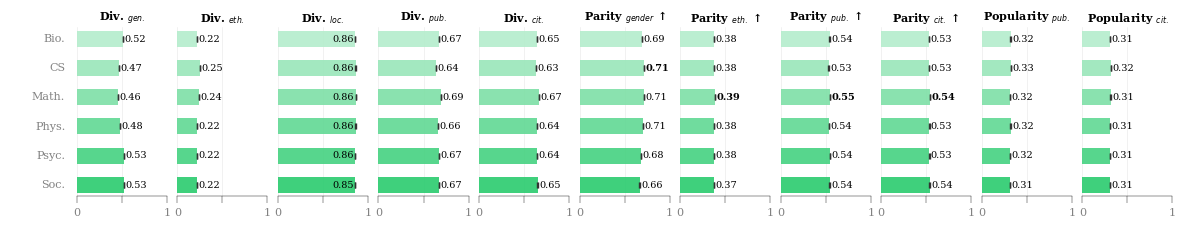

In [62]:

df_field = aggregate_scores(df_valid_calls, ['field_en'])
display(df_field)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_field.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_field,
        group_configs=[
            {'label': 'Field', 'column': 'field_en', 'color': '#2ECC71', 'order': FIELD_ORDER},
        ],
        row_labels=FIELD_MAP,
        metrics=metric_list,
        metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT + (len(FIELD_ORDER)/5))
    )


### Field and Language

,field_en,language,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,factuality_mean,factuality_ci,factuality_std,factuality_field_mean,factuality_field_ci,...,pct_med_works_ci,pct_med_works_std,pct_high_works_mean,pct_high_works_ci,pct_high_works_std,pct_low_citations_mean,pct_low_citations_ci,pct_low_citations_std,pct_med_citations_mean,pct_med_citations_ci,pct_med_citations_std,pct_high_citations_mean,pct_high_citations_ci,pct_high_citations_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,Biology,English,51600,0.8438,0.0031,0.3630,0.0722,0.0022,0.2588,0.0652,0.0012,0.1328,0.0013,0.0002,0.0250,0.9614,0.0014,0.1539,0.6073,0.0031,...,0.0032,0.3336,0.3276,0.0034,0.3541,0.3548,0.0037,0.3834,0.3284,0.0033,0.3405,0.3168,0.0034,0.3522,0.3276,0.0034,0.3541,0.3168,0.0034,0.3522
1,Biology,German,51600,0.8518,0.0031,0.3553,0.0566,0.0020,0.2311,0.0842,0.0015,0.1611,0.0012,0.0002,0.0241,0.9611,0.0015,0.1643,0.6274,0.0032,...,0.0034,0.3498,0.3270,0.0035,0.3639,0.3406,0.0038,0.3899,0.3522,0.0035,0.3624,0.3072,0.0035,0.3576,0.3270,0.0035,0.3639,0.3072,0.0035,0.3576
2,Biology,Spanish,51600,0.8912,0.0027,0.3114,0.0319,0.0015,0.1756,0.0850,0.0015,0.1618,0.0009,0.0002,0.0208,0.9566,0.0016,0.1714,0.6140,0.0030,...,0.0032,0.3411,0.3060,0.0033,0.3471,0.3616,0.0036,0.3857,0.3447,0.0033,0.3490,0.2937,0.0032,0.3456,0.3060,0.0033,0.3471,0.2937,0.0032,0.3456
3,Computer Science,English,51600,0.8548,0.0030,0.3523,0.0671,0.0022,0.2502,0.1022,0.0017,0.1791,0.0019,0.0003,0.0294,0.9607,0.0014,0.1551,0.3058,0.0049,...,0.0033,0.3420,0.3346,0.0035,0.3667,0.3408,0.0036,0.3770,0.3372,0.0033,0.3463,0.3220,0.0035,0.3611,0.3346,0.0035,0.3667,0.3220,0.0035,0.3611
4,Computer Science,German,51600,0.8592,0.0030,0.3478,0.0519,0.0019,0.2219,0.1102,0.0018,0.1896,0.0019,0.0003,0.0293,0.9588,0.0016,0.1677,0.3135,0.0054,...,0.0034,0.3585,0.3256,0.0036,0.3751,0.3363,0.0037,0.3868,0.3496,0.0035,0.3645,0.3141,0.0035,0.3683,0.3256,0.0036,0.3751,0.3141,0.0035,0.3683
5,Computer Science,Spanish,51600,0.8946,0.0027,0.3071,0.0294,0.0015,0.1690,0.1206,0.0019,0.2030,0.0020,0.0003,0.0298,0.9548,0.0016,0.1726,0.2870,0.0047,...,0.0033,0.3481,0.3156,0.0034,0.3652,0.3515,0.0036,0.3818,0.3393,0.0033,0.3494,0.3093,0.0034,0.3614,0.3156,0.0034,0.3652,0.3093,0.0034,0.3614
6,Mathematics,English,51600,0.8408,0.0032,0.3659,0.0718,0.0022,0.2581,0.0885,0.0015,0.1635,0.0018,0.0003,0.0281,0.9617,0.0014,0.1528,0.2968,0.0069,...,0.0033,0.3409,0.3180,0.0033,0.3439,0.3527,0.0037,0.3790,0.3408,0.0034,0.3467,0.3065,0.0034,0.3463,0.3180,0.0033,0.3439,0.3065,0.0034,0.3463
7,Mathematics,German,51600,0.8451,0.0031,0.3618,0.0578,0.0020,0.2334,0.0926,0.0016,0.1653,0.0017,0.0003,0.0295,0.9615,0.0015,0.1626,0.2963,0.0078,...,0.0034,0.3506,0.3253,0.0035,0.3566,0.3341,0.0037,0.3838,0.3416,0.0035,0.3575,0.3243,0.0035,0.3620,0.3253,0.0035,0.3566,0.3243,0.0035,0.3620
8,Mathematics,Spanish,51600,0.8772,0.0028,0.3282,0.0344,0.0016,0.1823,0.1028,0.0017,0.1837,0.0017,0.0003,0.0293,0.9575,0.0016,0.1683,0.2690,0.0067,...,0.0033,0.3451,0.3043,0.0032,0.3393,0.3552,0.0036,0.3815,0.3377,0.0033,0.3458,0.3071,0.0033,0.3467,0.3043,0.0032,0.3393,0.3071,0.0033,0.3467
9,Physics,English,51600,0.8409,0.0032,0.3657,0.0713,0.0022,0.2573,0.0739,0.0015,0.1549,0.0011,0.0002,0.0222,0.9512,0.0016,0.1739,0.3160,0.0059,...,0.0033,0.3400,0.3270,0.0035,0.3559,0.3492,0.0037,0.3804,0.3345,0.0033,0.3427,0.3163,0.0034,0.3525,0.3270,0.0035,0.3559,0.3163,0.0034,0.3525


technical
../../../results/plots/plot_technical_field_lang.pdf
Saved → ../../../results/plots/plot_technical_field_lang.pdf


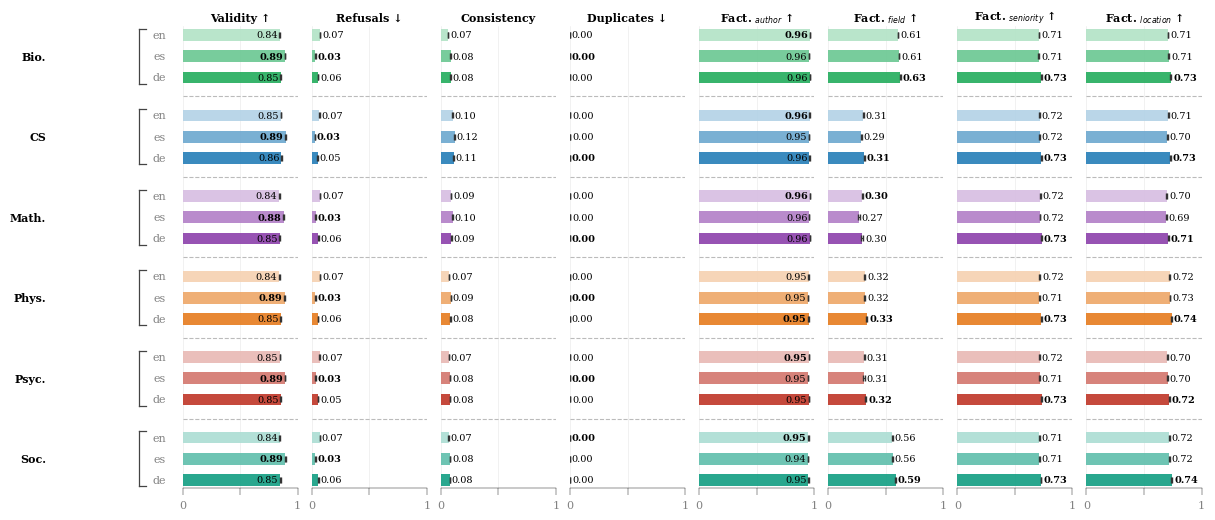

social
../../../results/plots/plot_social_field_lang.pdf
Saved → ../../../results/plots/plot_social_field_lang.pdf


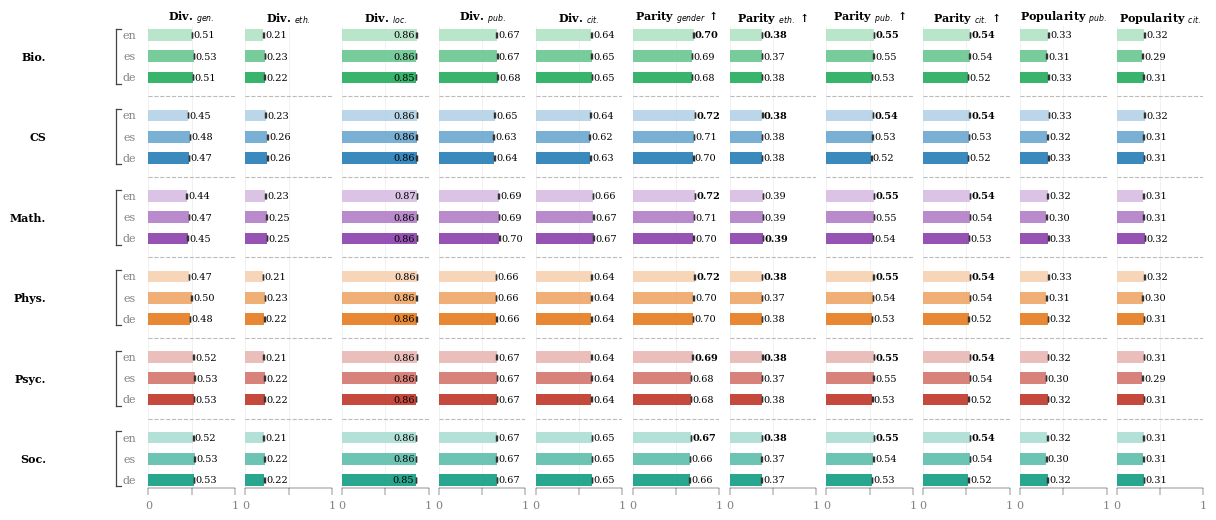

In [63]:

df_field_lang = aggregate_scores(df_valid_calls, ['field_en', 'language'])
display(df_field_lang)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_field_lang.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_field_lang,
        group_configs=[
            {'label': field_en, 'column': 'language', 'color': FIELD_COLORS[field_en], 'filter': {'field_en': field_en}, 'order': LANGUAGE_ORDER }for field_en in FIELD_ORDER
        ],
        section_labels=FIELD_MAP,
        row_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(FIELD_ORDER))
    )




### Field and K

,field_en,k,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,factuality_mean,factuality_ci,factuality_std,factuality_field_mean,factuality_field_ci,...,pct_med_works_ci,pct_med_works_std,pct_high_works_mean,pct_high_works_ci,pct_high_works_std,pct_low_citations_mean,pct_low_citations_ci,pct_low_citations_std,pct_med_citations_mean,pct_med_citations_ci,pct_med_citations_std,pct_high_citations_mean,pct_high_citations_ci,pct_high_citations_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,Biology,1,51600,0.9081,0.0025,0.2888,0.0323,0.0015,0.1769,0.1136,0.0019,0.2073,0.0003,0.0001,0.0135,0.9563,0.0018,0.2009,0.9742,0.0016,...,0.0044,0.4608,0.3274,0.0045,0.4646,0.3540,0.0046,0.4735,0.3538,0.0046,0.4730,0.2921,0.0043,0.4507,0.3274,0.0045,0.4646,0.2921,0.0043,0.4507
1,Biology,5,51600,0.8562,0.0030,0.3509,0.0571,0.0020,0.2320,0.0668,0.0011,0.1219,0.0010,0.0002,0.0245,0.9612,0.0013,0.1430,0.5408,0.0025,...,0.0027,0.2818,0.3239,0.0029,0.3035,0.3482,0.0033,0.3490,0.3337,0.0027,0.2887,0.3181,0.0029,0.3074,0.3239,0.0029,0.3035,0.3181,0.0029,0.3074
2,Biology,10,51600,0.8224,0.0033,0.3822,0.0713,0.0022,0.2573,0.0512,0.0009,0.0920,0.0022,0.0003,0.0297,0.9616,0.0013,0.1350,0.5030,0.0022,...,0.0024,0.2448,0.3084,0.0026,0.2680,0.3555,0.0031,0.3214,0.3383,0.0024,0.2528,0.3062,0.0026,0.2735,0.3084,0.0026,0.2680,0.3062,0.0026,0.2735
3,Computer Science,1,51600,0.9128,0.0024,0.2821,0.0311,0.0015,0.1735,0.1608,0.0023,0.2558,0.0002,0.0001,0.0100,0.9559,0.0018,0.2019,0.9305,0.0061,...,0.0045,0.4648,0.3456,0.0045,0.4711,0.3265,0.0044,0.4636,0.3548,0.0045,0.4725,0.3187,0.0044,0.4616,0.3456,0.0045,0.4711,0.3187,0.0044,0.4616
4,Computer Science,5,51600,0.8657,0.0029,0.3410,0.0519,0.0019,0.2217,0.0936,0.0014,0.1508,0.0013,0.0002,0.0260,0.9597,0.0014,0.1460,0.2974,0.0032,...,0.0028,0.2947,0.3251,0.0030,0.3244,0.3450,0.0033,0.3491,0.3347,0.0028,0.2966,0.3203,0.0030,0.3229,0.3251,0.0030,0.3244,0.3203,0.0030,0.3229
5,Computer Science,10,51600,0.8302,0.0032,0.3755,0.0655,0.0021,0.2475,0.0748,0.0012,0.1215,0.0045,0.0004,0.0437,0.9587,0.0013,0.1377,0.1854,0.0021,...,0.0024,0.2560,0.3048,0.0027,0.2863,0.3573,0.0030,0.3187,0.3368,0.0024,0.2552,0.3059,0.0027,0.2839,0.3048,0.0027,0.2863,0.3059,0.0027,0.2839
6,Mathematics,1,51600,0.9097,0.0025,0.2866,0.0294,0.0015,0.1689,0.1373,0.0021,0.2313,0.0002,0.0001,0.0110,0.9575,0.0018,0.1986,0.9435,0.0078,...,0.0045,0.4697,0.3090,0.0044,0.4568,0.3444,0.0045,0.4708,0.3537,0.0046,0.4734,0.3020,0.0044,0.4541,0.3090,0.0044,0.4568,0.3020,0.0044,0.4541
7,Mathematics,5,51600,0.8471,0.0031,0.3599,0.0601,0.0021,0.2377,0.0786,0.0012,0.1319,0.0014,0.0003,0.0278,0.9616,0.0013,0.1420,0.2818,0.0043,...,0.0027,0.2812,0.3238,0.0028,0.2944,0.3465,0.0033,0.3435,0.3317,0.0027,0.2870,0.3218,0.0029,0.3055,0.3238,0.0028,0.2944,0.3218,0.0029,0.3055
8,Mathematics,10,51600,0.8062,0.0034,0.3953,0.0745,0.0023,0.2626,0.0636,0.0010,0.1067,0.0038,0.0004,0.0415,0.9619,0.0013,0.1311,0.1673,0.0027,...,0.0023,0.2419,0.3139,0.0025,0.2551,0.3517,0.0030,0.3116,0.3347,0.0024,0.2466,0.3136,0.0026,0.2673,0.3139,0.0025,0.2551,0.3136,0.0026,0.2673
9,Physics,1,51600,0.9072,0.0025,0.2901,0.0316,0.0015,0.1749,0.1230,0.0020,0.2262,0.0003,0.0001,0.0123,0.9462,0.0020,0.2224,0.9506,0.0056,...,0.0045,0.4642,0.3298,0.0045,0.4648,0.3453,0.0046,0.4705,0.3510,0.0046,0.4714,0.3036,0.0044,0.4553,0.3298,0.0045,0.4648,0.3036,0.0044,0.4553


technical
../../../results/plots/plot_technical_field_k.pdf
Saved → ../../../results/plots/plot_technical_field_k.pdf


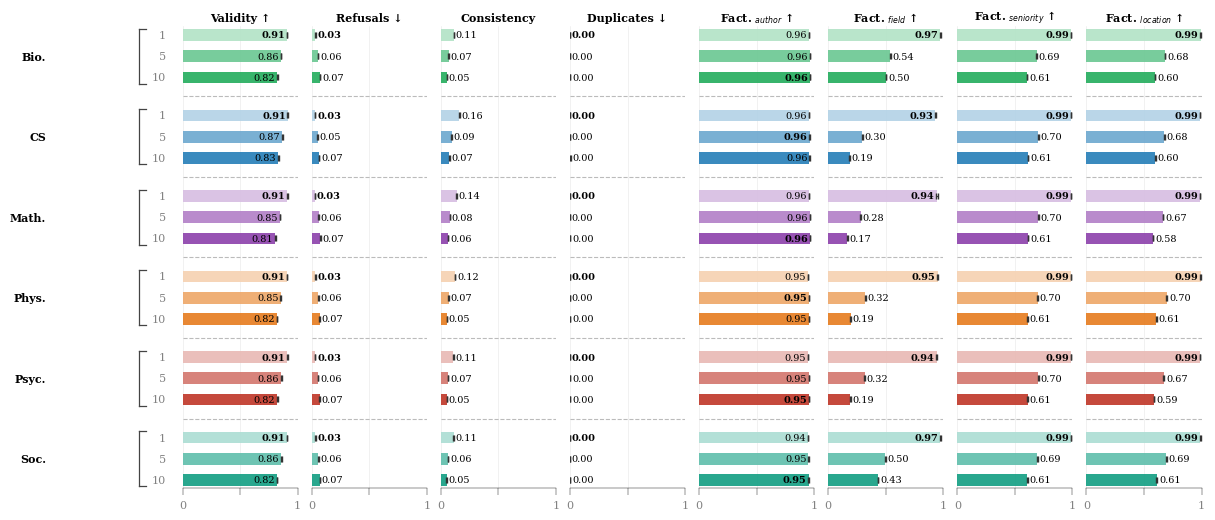

social
../../../results/plots/plot_social_field_k.pdf
Saved → ../../../results/plots/plot_social_field_k.pdf


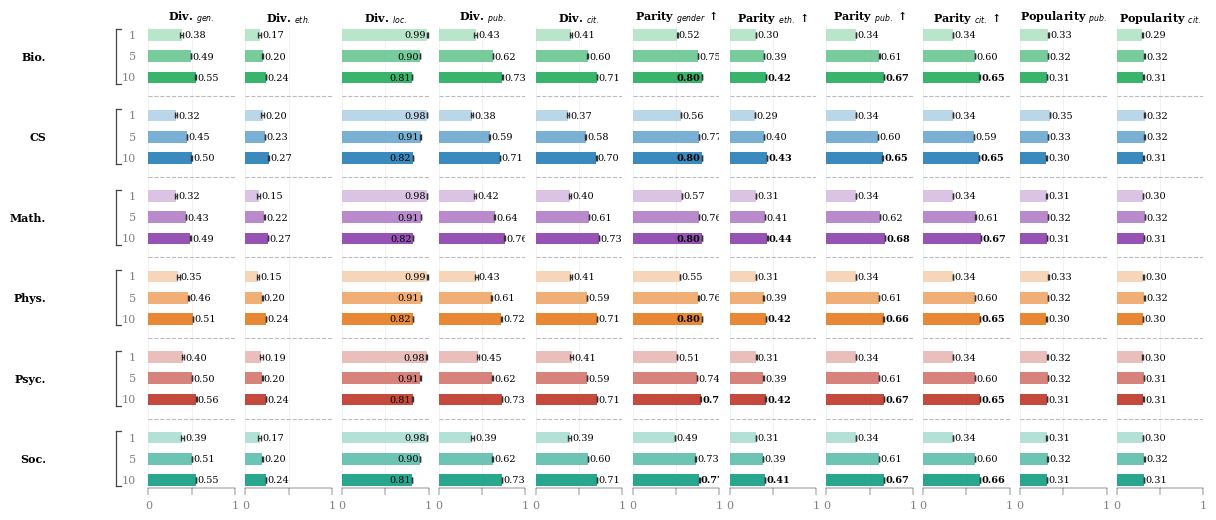

In [64]:

df_field_k = aggregate_scores(df_valid_calls, ['field_en', 'k'])
display(df_field_k)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_field_k.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_field_k,
        group_configs=[
            {'label': field_en, 'column': 'k', 'color': FIELD_COLORS[field_en], 'filter': {'field_en': field_en}, 'order': K_ORDER }for field_en in FIELD_ORDER
        ],
        section_labels=FIELD_MAP,
        metrics=metric_list,
        metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(FIELD_ORDER))
    )




## Seniority (target)

,target_en,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,factuality_mean,factuality_ci,factuality_std,factuality_field_mean,factuality_field_ci,factuality_field_std,...,pct_med_works_ci,pct_med_works_std,pct_high_works_mean,pct_high_works_ci,pct_high_works_std,pct_low_citations_mean,pct_low_citations_ci,pct_low_citations_std,pct_med_citations_mean,pct_med_citations_ci,pct_med_citations_std,pct_high_citations_mean,pct_high_citations_ci,pct_high_citations_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,Junior Professor,464400,0.8565,0.0010,0.3506,0.0575,0.0007,0.2328,0.0748,0.0005,0.1488,0.0012,0.0001,0.0250,0.9519,0.0006,0.1773,0.4945,0.0017,0.3195,...,0.0011,0.3477,0.2756,0.0011,0.3351,0.3680,0.0012,0.3896,0.3629,0.0011,0.3536,0.2691,0.0011,0.3333,0.2756,0.0011,0.3351,0.2691,0.0011,0.3333
1,Senior Professor,464400,0.8672,0.0010,0.3394,0.0478,0.0006,0.2133,0.0981,0.0006,0.1780,0.0018,0.0001,0.0295,0.9575,0.0005,0.1673,0.4839,0.0016,0.3186,...,0.0011,0.3389,0.3600,0.0012,0.3695,0.3348,0.0012,0.3793,0.3150,0.0011,0.3419,0.3502,0.0012,0.3709,0.3600,0.0012,0.3695,0.3502,0.0012,0.3709


technical
../../../results/plots/plot_technical_seniority.pdf
Saved → ../../../results/plots/plot_technical_seniority.pdf


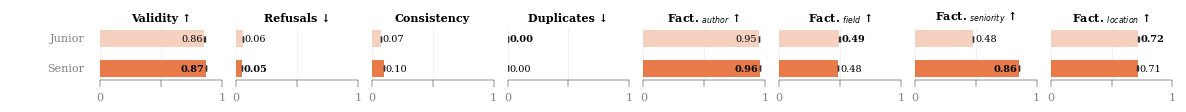

social
../../../results/plots/plot_social_seniority.pdf
Saved → ../../../results/plots/plot_social_seniority.pdf


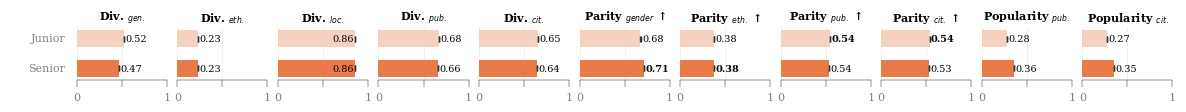

In [65]:

df_target = aggregate_scores(df_valid_calls, ['target_en'])
display(df_target)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_seniority.pdf')
    print(fn)
        
    plot_grouped_metrics_labeled(
        df_target,
        group_configs=[
            {'label': 'Target', 'column': 'target_en', 'color': '#E8703A','order': SENIORITY_ORDER},
        ],
        row_labels=SENIORITY_MAP,
        metrics=metric_list,
        metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * 0.7)
    )

### Seniority and Language

,target_en,language,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,factuality_mean,factuality_ci,factuality_std,factuality_field_mean,factuality_field_ci,...,pct_med_works_ci,pct_med_works_std,pct_high_works_mean,pct_high_works_ci,pct_high_works_std,pct_low_citations_mean,pct_low_citations_ci,pct_low_citations_std,pct_med_citations_mean,pct_med_citations_ci,pct_med_citations_std,pct_high_citations_mean,pct_high_citations_ci,pct_high_citations_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std
0,Junior Professor,English,154800,0.8408,0.0018,0.3659,0.0749,0.0013,0.2632,0.0635,0.0007,0.1316,0.0010,0.0001,0.0219,0.9511,0.0009,0.1740,0.4837,0.0029,...,0.0019,0.3414,0.2795,0.0019,0.3320,0.3698,0.0022,0.3861,0.3573,0.0019,0.3464,0.2729,0.0018,0.3304,0.2795,0.0019,0.3320,0.2729,0.0018,0.3304
1,Junior Professor,German,154800,0.8447,0.0018,0.3622,0.0613,0.0012,0.2399,0.0782,0.0008,0.1520,0.0014,0.0002,0.0277,0.9543,0.0010,0.1764,0.5119,0.0031,...,0.0020,0.3541,0.2853,0.0019,0.3463,0.3561,0.0022,0.3936,0.3684,0.0020,0.3638,0.2755,0.0019,0.3425,0.2853,0.0019,0.3463,0.2755,0.0019,0.3425
2,Junior Professor,Spanish,154800,0.8840,0.0016,0.3203,0.0363,0.0009,0.1871,0.0823,0.0008,0.1601,0.0013,0.0001,0.0249,0.9505,0.0010,0.1812,0.4892,0.0029,...,0.0019,0.3475,0.2627,0.0018,0.3268,0.3774,0.0021,0.3887,0.3631,0.0019,0.3505,0.2595,0.0018,0.3271,0.2627,0.0018,0.3268,0.2595,0.0018,0.3271
3,Senior Professor,English,154800,0.8500,0.0018,0.3571,0.0653,0.0012,0.2471,0.0920,0.0009,0.1700,0.0020,0.0002,0.0308,0.9620,0.0008,0.1519,0.4772,0.0027,...,0.0019,0.3321,0.3682,0.0021,0.3675,0.3315,0.0021,0.3738,0.3128,0.0019,0.3366,0.3557,0.0021,0.3686,0.3682,0.0021,0.3675,0.3557,0.0021,0.3686
4,Senior Professor,German,154800,0.8587,0.0017,0.3484,0.0500,0.0011,0.2180,0.0986,0.0010,0.1774,0.0018,0.0002,0.0301,0.9577,0.0009,0.1706,0.4975,0.0029,...,0.0019,0.3477,0.3632,0.0021,0.3765,0.3289,0.0021,0.3832,0.3185,0.0020,0.3509,0.3526,0.0021,0.3770,0.3632,0.0021,0.3765,0.3526,0.0021,0.3770
5,Senior Professor,Spanish,154800,0.8929,0.0015,0.3093,0.0280,0.0008,0.1650,0.1035,0.0010,0.1858,0.0016,0.0001,0.0276,0.9529,0.0009,0.1775,0.4779,0.0027,...,0.0018,0.3369,0.3490,0.0020,0.3644,0.3436,0.0021,0.3805,0.3138,0.0018,0.3383,0.3426,0.0020,0.3672,0.3490,0.0020,0.3644,0.3426,0.0020,0.3672


technical
../../../results/plots/plot_technical_seniority_lang.pdf
Saved → ../../../results/plots/plot_technical_seniority_lang.pdf


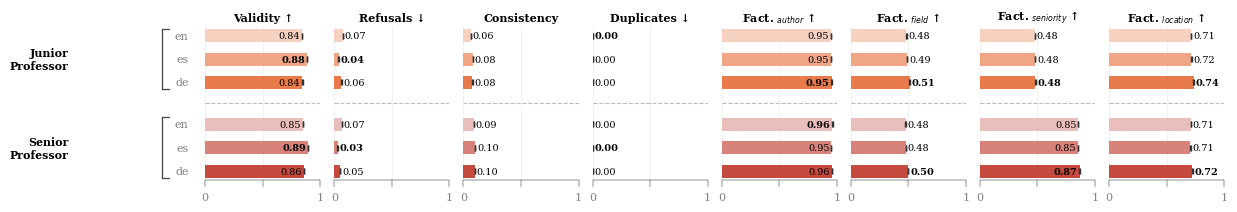

social
../../../results/plots/plot_social_seniority_lang.pdf
Saved → ../../../results/plots/plot_social_seniority_lang.pdf


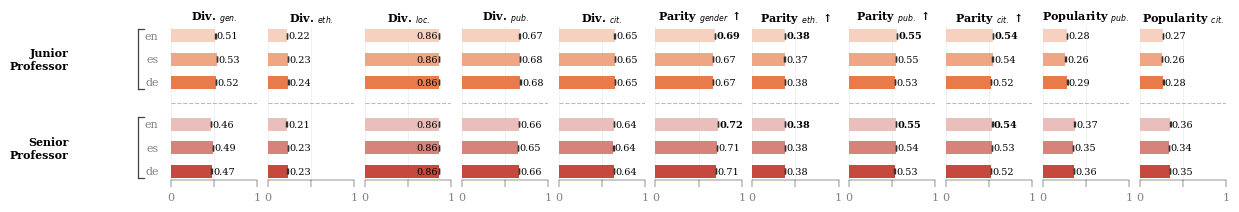

In [66]:

df_target_lang = aggregate_scores(df_valid_calls, ['target_en', 'language'])
display(df_target_lang)

for metric_type, metric_list in METRIC_TYPES.items():
    
    print(metric_type)
    
    fn = str(PLOTS_DIR / f'plot_{metric_type}_seniority_lang.pdf')
    print(fn)

    plot_grouped_metrics_labeled(
        df_target_lang,
        group_configs=[
            {'label': target_en, 'column': 'language', 'color': SENIORITY_COLORS[target_en],
            'filter': {'target_en': target_en}, 'order': LANGUAGE_ORDER}
            for target_en in SENIORITY_ORDER
        ],
        row_labels=LANGUAGE_MAP,
        metrics=metric_list,
        metric_directions=PLOT_DIRS,
        metric_labels=PLOT_LABELS,
        save_path=fn,
        figsize=(FIG_WIDTH, FIG_HEIGHT * len(SENIORITY_ORDER))
    )

# RQ3: Insfrastructure

In [67]:

df_infra = pd.DataFrame()
for c in ['model_access','model_size','model_class']:
    tmp = aggregate_scores(df_valid_calls, [c]).rename(columns={c: 'label'})
    tmp.loc[:,'section'] = MODEL_ARCHITECTURE_MAP[c]
    df_infra = pd.concat([df_infra, tmp], ignore_index=True)

display(df_infra)


# for metric_type, metric_list in METRIC_TYPES.items():
    
#     print(metric_type)
    
#     fn = str(PLOTS_DIR / f'plot_infrastructure_{metric_type}.pdf')
#     print(fn)

#     plot_grouped_metrics_labeled(
#         df_infra,
#         group_configs=[
#             {'label': MODEL_ARCHITECTURE['model_access'], 'column': 'model_access', 'color': '#4A90D9', 'order': ACCESS_ORDER},
#             {'label': MODEL_ARCHITECTURE['model_size'],   'column': 'model_size',   'color': '#5DB85D', 'order': SIZE_ORDER},
#             {'label': MODEL_ARCHITECTURE['model_class'],   'column': 'model_class',   'color': '#E74C3C', 'order': REASONING_ORDER},
#         ],
#         row_labels=ACCESS_MAP | SIZE_MAP,
#         metrics=metric_list,
#         metric_directions=PLOT_DIRS,
#         metric_labels=PLOT_LABELS,
#         save_path=fn,
#         figsize=(FIG_WIDTH, FIG_HEIGHT * 2.8)
#     )



,label,n,validity_mean,validity_ci,validity_std,refusals_mean,refusals_ci,refusals_std,consistency_mean,consistency_ci,consistency_std,duplicates_mean,duplicates_ci,duplicates_std,factuality_mean,factuality_ci,factuality_std,factuality_field_mean,factuality_field_ci,factuality_field_std,...,pct_med_works_std,pct_high_works_mean,pct_high_works_ci,pct_high_works_std,pct_low_citations_mean,pct_low_citations_ci,pct_low_citations_std,pct_med_citations_mean,pct_med_citations_ci,pct_med_citations_std,pct_high_citations_mean,pct_high_citations_ci,pct_high_citations_std,popularity_works_mean,popularity_works_ci,popularity_works_std,popularity_citations_mean,popularity_citations_ci,popularity_citations_std,section
0,open-weight,799200,0.8539,0.0008,0.3532,0.0501,0.0005,0.2182,0.0866,0.0004,0.1656,0.0017,0.0001,0.0295,0.9514,0.0004,0.1805,0.4978,0.0013,0.3220,...,0.3448,0.3223,0.0009,0.3567,0.3492,0.0010,0.3882,0.3353,0.0009,0.3502,0.3155,0.0009,0.3573,0.3223,0.0009,0.3567,0.3155,0.0009,0.3573,Access
1,proprietary,129600,0.9104,0.0016,0.2856,0.0682,0.0014,0.2521,0.0864,0.0009,0.1589,0.0001,0.0000,0.0068,0.9741,0.0006,0.1121,0.4470,0.0026,0.3015,...,0.3369,0.2925,0.0020,0.3457,0.3637,0.0021,0.3651,0.3598,0.0020,0.3388,0.2765,0.0020,0.3395,0.2925,0.0020,0.3457,0.2765,0.0020,0.3395,Access
2,L,172800,0.9643,0.0009,0.1855,0.0164,0.0006,0.1269,0.1028,0.0008,0.1611,0.0002,0.0000,0.0080,0.9805,0.0005,0.1047,0.4808,0.0024,0.3109,...,0.3408,0.3591,0.0017,0.3550,0.2763,0.0017,0.3477,0.3686,0.0017,0.3447,0.3551,0.0017,0.3563,0.3591,0.0017,0.3550,0.3551,0.0017,0.3563,Size
3,M,345600,0.8758,0.0011,0.3298,0.0678,0.0008,0.2513,0.0950,0.0006,0.1806,0.0010,0.0001,0.0204,0.9681,0.0005,0.1445,0.4911,0.0019,0.3200,...,0.3505,0.3315,0.0013,0.3581,0.3180,0.0014,0.3771,0.3540,0.0013,0.3544,0.3280,0.0013,0.3600,0.3315,0.0013,0.3581,0.3280,0.0013,0.3600,Size
4,S,216000,0.9001,0.0013,0.2998,0.0403,0.0008,0.1966,0.0595,0.0006,0.1276,0.0014,0.0001,0.0240,0.9403,0.0008,0.1891,0.4867,0.0024,0.3202,...,0.3293,0.2812,0.0016,0.3493,0.4363,0.0018,0.3984,0.3009,0.0016,0.3378,0.2628,0.0016,0.3439,0.2812,0.0016,0.3493,0.2628,0.0016,0.3439,Size
5,T,151200,0.7372,0.0022,0.4402,0.0488,0.0011,0.2155,0.0462,0.0006,0.1089,0.0055,0.0003,0.0558,0.9015,0.0015,0.2634,0.5009,0.0034,0.3280,...,0.3443,0.2626,0.0022,0.3414,0.4394,0.0025,0.4023,0.3082,0.0022,0.3474,0.2524,0.0021,0.3360,0.2626,0.0022,0.3414,0.2524,0.0021,0.3360,Size
6,XL,43200,0.5846,0.0046,0.4928,0.1522,0.0034,0.3592,0.2631,0.0033,0.2682,0.0001,0.0001,0.0048,0.9703,0.0016,0.1275,0.4883,0.0063,0.3196,...,0.3476,0.3711,0.0046,0.3657,0.2655,0.0044,0.3494,0.3693,0.0045,0.3555,0.3652,0.0047,0.3690,0.3711,0.0046,0.3657,0.3652,0.0047,0.3690,Size
7,False,691200,0.8547,0.0008,0.3524,0.0518,0.0005,0.2216,0.0921,0.0004,0.1729,0.0018,0.0001,0.0303,0.9485,0.0005,0.1852,0.4867,0.0014,0.3197,...,0.3414,0.3090,0.0009,0.3492,0.3646,0.0010,0.3892,0.3348,0.0009,0.3470,0.3006,0.0009,0.3490,0.3090,0.0009,0.3492,0.3006,0.0009,0.3490,Reasoning
8,True,237600,0.8825,0.0013,0.3220,0.0551,0.0009,0.2282,0.0708,0.0006,0.1374,0.0006,0.0001,0.0165,0.9721,0.0005,0.1278,0.4946,0.0022,0.3171,...,0.3500,0.3414,0.0016,0.3700,0.3156,0.0016,0.3703,0.3504,0.0015,0.3529,0.3340,0.0016,0.3695,0.3414,0.0016,0.3700,0.3340,0.0016,0.3695,Reasoning


# RQ4: Socio-Technical Trade-off

In [104]:
import numpy as np
from adjustText import adjust_text

def annotate_smart(ax, x, y, labels, colors,
                   move_threshold=0.01,
                   fontsize=9,
                   line_kwargs=None,
                   **adjust_kwargs):
    """Label points with connectors only for moved labels, colored per point.

    move_threshold : fraction of axis range. A label is considered "moved"
                     if its displacement exceeds this. 0.01 = 1% of axes.
    """
    line_kwargs = {"arrowstyle": "-", "lw": 0.5, "alpha": 0.7, **(line_kwargs or {})}

    # 1. Place labels at their points, colored
    texts = [ax.text(xi, yi, lbl, fontsize=fontsize, color=c)
             for xi, yi, lbl, c in zip(x, y, labels, colors)]

    # 2. Let adjustText reposition — no arrows yet
    adjust_text(texts, ax=ax, **adjust_kwargs)

    # 3. Normalize displacement against axis ranges
    (x0, x1), (y0, y1) = ax.get_xlim(), ax.get_ylim()
    xr, yr = x1 - x0, y1 - y0

    # 4. Replace each text: add a connector only if it actually moved
    annotations = []
    for txt, xi, yi, lbl, c in zip(texts, x, y, labels, colors):
        tx, ty = txt.get_position()
        moved = np.hypot((tx - xi) / xr, (ty - yi) / yr) > move_threshold
        txt.remove()

        if moved:
            ann = ax.annotate(
                lbl, xy=(xi, yi), xytext=(tx, ty),
                fontsize=fontsize, color=c,
                arrowprops={**line_kwargs, "color": c},
            )
        else:
            ann = ax.text(tx, ty, lbl, fontsize=fontsize, color=c)
        annotations.append(ann)

    return annotations

import numpy as np


def quadrant_annotate(ax, x, y, labels, colors,
                      x_threshold=None, y_threshold=None,
                      offset=15, fontsize=9,
                      line_kwargs=None):
    """Coloca labels en el cuadrante "exterior" de cada punto.

    - x < umbral_x  →  label a la izquierda
    - x > umbral_x  →  label a la derecha
    - y > umbral_y  →  label arriba
    - y < umbral_y  →  label abajo

    Los conectores heredan el color del punto.
    """
    x, y = np.asarray(x), np.asarray(y)
    x_threshold = np.mean(x) if x_threshold is None else x_threshold
    y_threshold = np.mean(y) if y_threshold is None else y_threshold

    line_defaults = {"arrowstyle": "-", "lw": 0.5, "alpha": 0.6,
                     "shrinkA": 0, "shrinkB": 3}
    line_kwargs = {**line_defaults, **(line_kwargs or {})}

    annotations = []
    for xi, yi, lbl, c in zip(x, y, labels, colors):
        right = xi > x_threshold
        up    = yi > y_threshold

        dx = offset if right else -offset
        dy = offset if up    else -offset
        ha = "left" if right else "right"
        va = "bottom" if up   else "top"

        ann = ax.annotate(
            lbl,
            xy=(xi, yi),
            xytext=(dx, dy),
            textcoords="offset points",
            ha=ha, va=va,
            fontsize=fontsize, color=c,
            arrowprops={**line_kwargs, "color": c},
        )
        annotations.append(ann)
    return annotations

Scatter — 43 models
Technical max: 6.399, Social max: 2.371
Saved → ../../../results/plots/plot_technical_vs_social.pdf


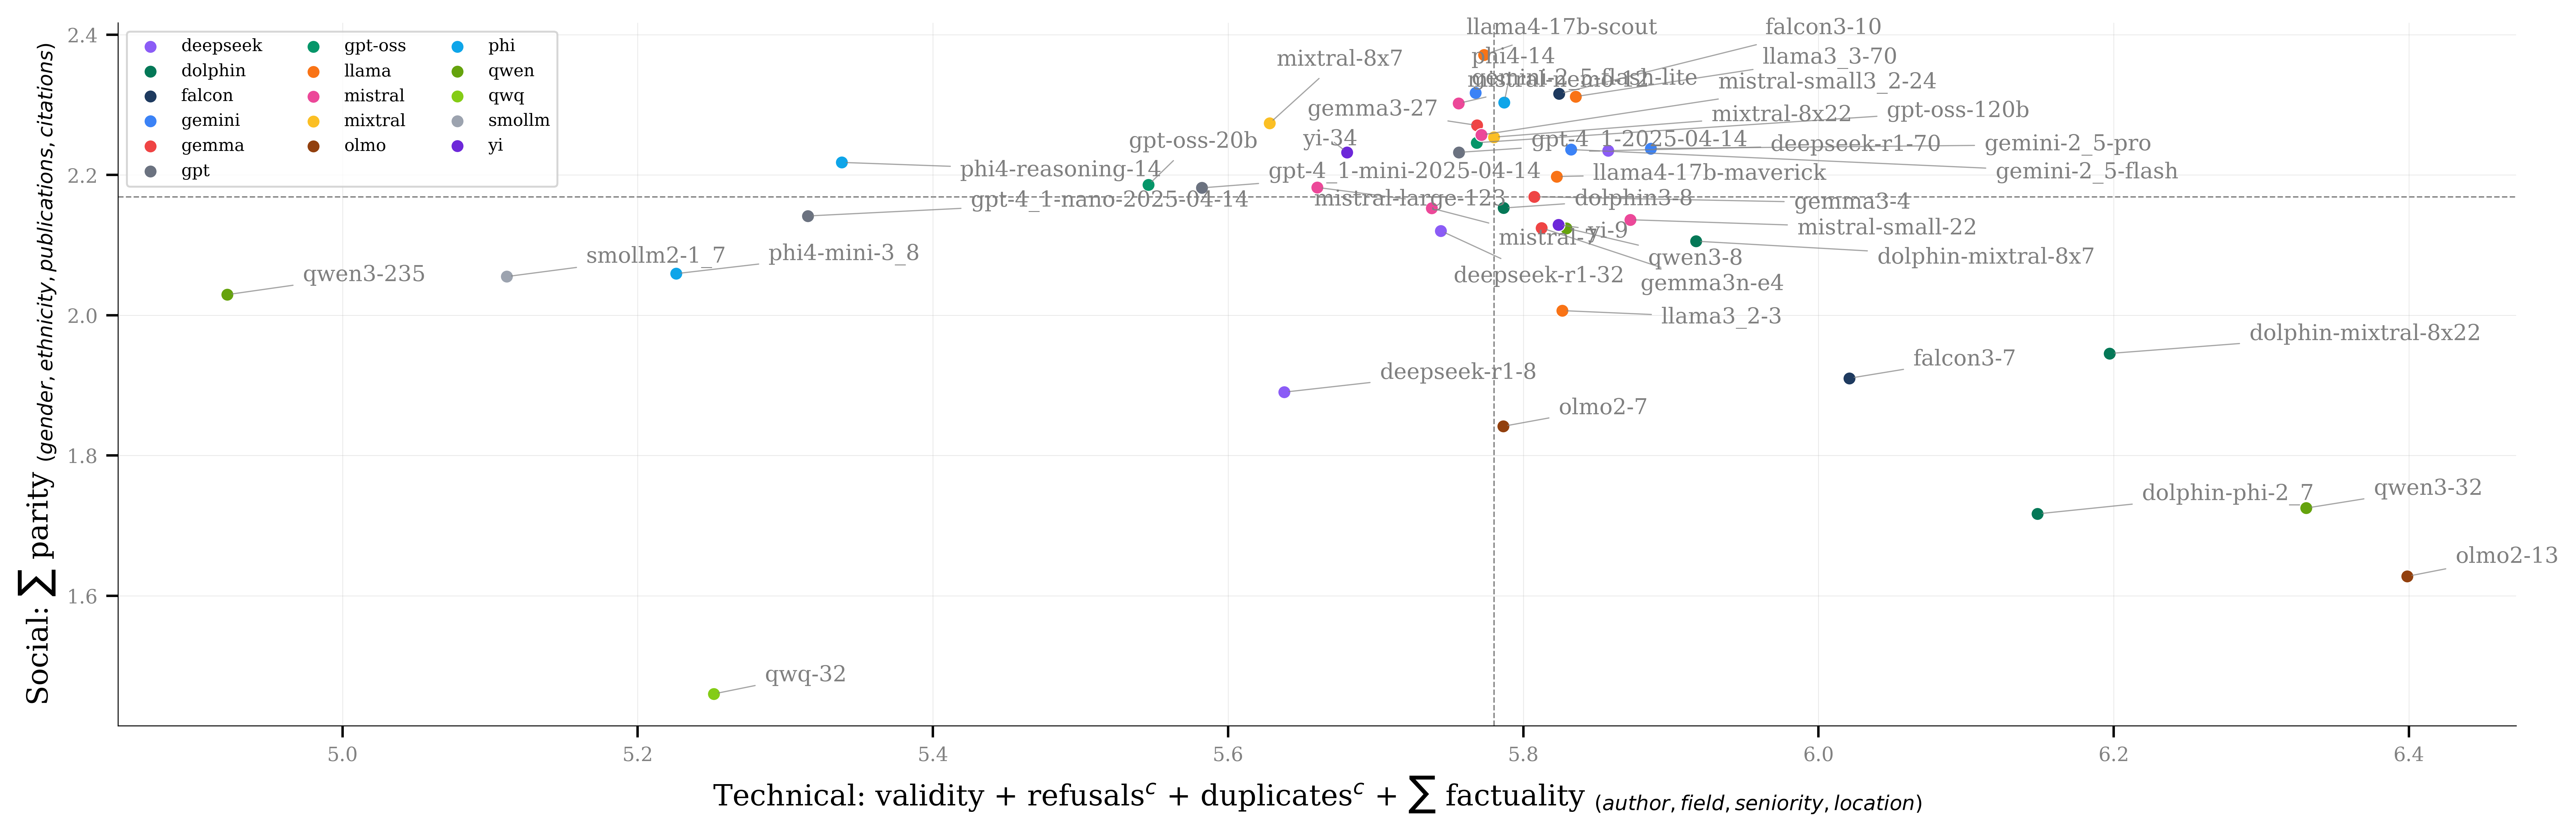

In [107]:
# ── Scatter: Social (∑ parity) vs Technical (∑ factuality + duplicates + factuality_location) ──
# One dot per model, colored by family, labeled with model name.
# Dashed lines at the median of each axis.

df_data_tmp = df_valid_calls.copy()

if 'duplicates_c' not in df_data_tmp.columns:
    df_data_tmp.loc[:,'duplicates_c'] = df_data_tmp.loc[:,'duplicates'].apply(lambda val: 1-val if pd.notna(val) else np.nan)

if 'refusals_c' not in df_data_tmp.columns:
    df_data_tmp.loc[:,'refusals_c'] = df_data_tmp.loc[:,'refusals'].apply(lambda val: 1-val if pd.notna(val) else np.nan)

df_data_tmp.loc[:,'model_short_name'] = df_data_tmp.model.apply(lambda m: m.split('b-')[0] if not m.startswith('llama4-17b') else m.split('-16e-')[0].split('-128e-')[0])
df_data_tmp.loc[:, 'color'] = 'gray' # df_data_tmp['model_family'].map(MODEL_FAMILY_COLORS).fillna('#6B7280')

# Aggregate per model (mean over experimental cells, then over runs already inside per_cell)
agg_cols = TECHNICAL_METRICS + PARITY_METRICS

per_model_mean = (df_data_tmp.groupby(['model_short_name','model_family', 'color'], dropna=False)[agg_cols]
                  .mean()
                  .reset_index())
per_model_std = (df_data_tmp.groupby(['model_short_name','model_family', 'color'], dropna=False)[agg_cols]
                  .std()
                  .reset_index())

per_model_mean['x_technical'] = per_model_mean[TECHNICAL_METRICS].sum(axis=1, skipna=False)
per_model_mean['y_social']    = per_model_mean[SOCIAL_METRICS].sum(axis=1, skipna=False)

per_model_std['x_technical'] = per_model_std[TECHNICAL_METRICS].sum(axis=1, skipna=False)
per_model_std['y_social']    = per_model_std[SOCIAL_METRICS].sum(axis=1, skipna=False)

print(f'Scatter — {per_model_mean.model_short_name.nunique()} models')
print(f"Technical max: {per_model_mean['x_technical'].max():.3f}, Social max: {per_model_mean['y_social'].max():.3f}")

fig, ax = plt.subplots(figsize=(FIG_WIDTH,5), dpi=FIG_DPI)

# Median reference lines
x_med = per_model_mean['x_technical'].median()
y_med = per_model_mean['y_social'].median()
ax.axvline(x_med, color='#888', lw=0.6, ls='--', zorder=1)
ax.axhline(y_med, color='#888', lw=0.6, ls='--', zorder=1)

# Plot one family at a time for a clean legend
for fam, grp in per_model_mean.groupby('model_family'):
    ax.scatter(grp['x_technical'], grp['y_social'],
               s=28, color=MODEL_FAMILY_COLORS.get(fam, '#6B7280'),
               edgecolor='white', linewidth=0.4, label=fam, zorder=3)

annotate_smart(
    ax,
    x=per_model_mean["x_technical"],
    y=per_model_mean["y_social"],
    labels=per_model_mean["model_short_name"],
    colors=per_model_mean["color"],          # same color you used for the scatter
    move_threshold=0.015,        # tune: higher = fewer lines
    expand_points=(1.5, 1.8),
    force_text=(0.6, 0.9),
)

# quadrant_annotate(
#     ax,
#     x=per_model_mean["x_technical"],
#     y=per_model_mean["y_social"],
#     labels=per_model_mean["model_short_name"],
#     colors=per_model_mean["color"], 
#     x_threshold=per_model_mean["x_technical"].median(),
#     y_threshold=per_model_mean["y_social"].median(), 
#     offset=18,
# )

# texts = [
#             ax.text(r['x_technical'], r['y_social'], r['model_short_name'], fontsize=9, color=MODEL_FAMILY_COLORS.get(r['model_family'], '#6B7280'), zorder=1)
#             for _, r in per_model_mean.iterrows()
#         ]

# adjust_text(
#     texts,
#     ax=ax,
#     arrowprops=dict(arrowstyle="-", color="gray", lw=0.5, alpha=0.6),
#     expand_points=(1.4, 1.6),   # how far labels are pushed from points
#     expand_text=(1.2, 1.4),     # how far labels are pushed from each other
#     force_points=(0.4, 0.6),
#     force_text=(0.5, 0.8),
#     connectionstyle="arc3,rad=0.2"
# )

# Per-point labels
# for index, r in per_model_mean.iterrows():
#     if pd.notna(r['x_technical']) and pd.notna(r['y_social']):
 
#         ax.annotate(r['model_short_name'], (r['x_technical'], r['y_social']),
#                     xytext=(4, 1), textcoords='offset points',
#                     fontsize=8, color='#333', zorder=4)

#         # ax.errorbar(
#         #     r['x_technical'], 
#         #     r['y_social'],
#         #     xerr=per_model_std.loc[index, 'x_technical'],  # Assuming standard deviation as error
#         #     yerr=per_model_std.loc[index, 'y_social'],
#         #     fmt='o',          # marker style
#         #     capsize=4,        # size of error bar caps
#         #     elinewidth=1,
#         #     markersize=6
#         # )


# ax.set_xlim((0, len(TECHNICAL_METRICS)))
# ax.set_ylim((0, len(SOCIAL_METRICS)))

ax.set_xlabel(r'Technical: validity + refusals$^c$ + duplicates$^c$ + $\sum$ factuality $_{(author, field, seniority, location)}$',fontsize=12)
ax.set_ylabel(r'Social: $\sum$ parity $_{(gender, ethnicity, publications, citations)}$', fontsize=12)
ax.tick_params(axis='both', labelsize=8, labelcolor=TICK_COLOR)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
for sp in ('left', 'bottom'):
    ax.spines[sp].set_linewidth(0.4)
ax.grid(True, lw=0.3, alpha=0.3, zorder=0)
ax.legend(loc='best', fontsize=7, frameon=True, ncol=3)

fig.tight_layout()

fn = PLOTS_DIR / 'plot_technical_vs_social.pdf'
if fn:
    fig.savefig(fn, bbox_inches='tight', dpi=FIG_DPI)

print(f"Saved → {fn}")
plt.show()


KeyError: 'English'

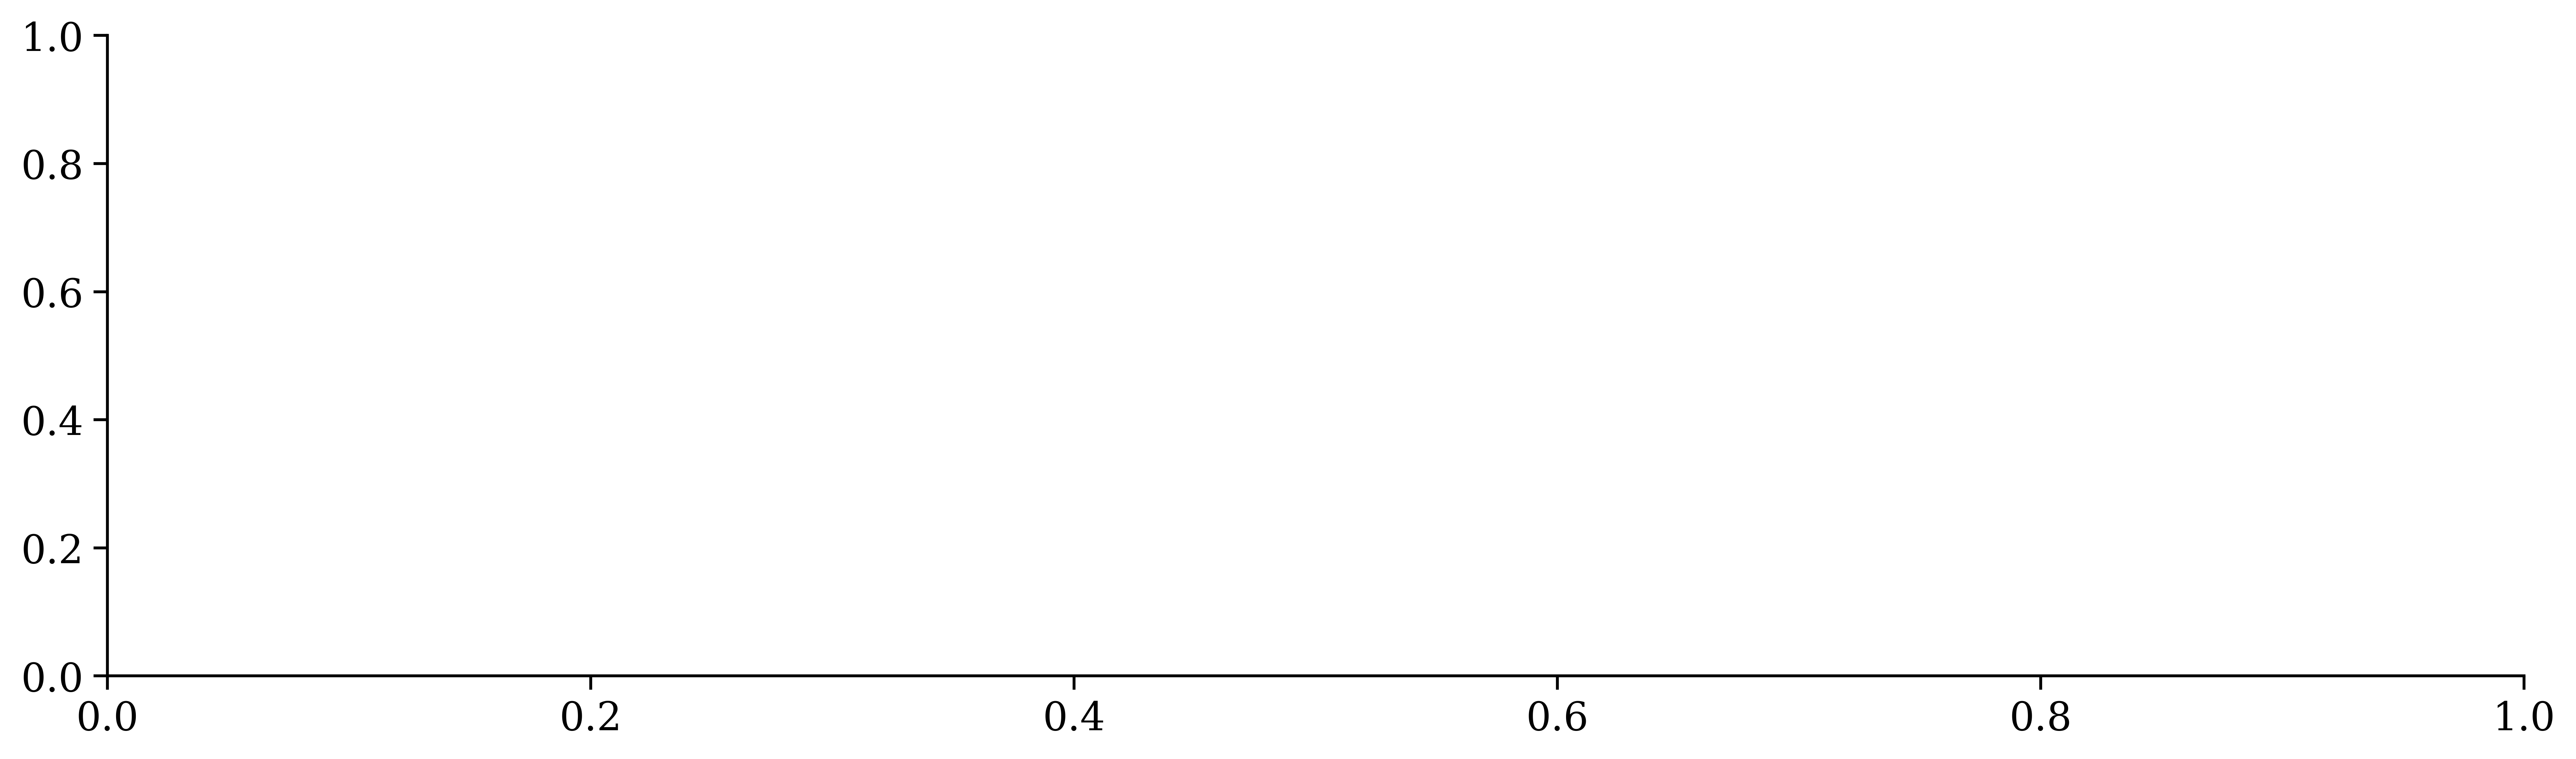

In [124]:

# df_data_tmp = df_valid_calls.copy()

# if 'duplicates_c' not in df_data_tmp.columns:
#     df_data_tmp.loc[:,'duplicates_c'] = df_data_tmp.loc[:,'duplicates'].apply(lambda val: 1-val if pd.notna(val) else np.nan)

# if 'refusals_c' not in df_data_tmp.columns:
#     df_data_tmp.loc[:,'refusals_c'] = df_data_tmp.loc[:,'refusals'].apply(lambda val: 1-val if pd.notna(val) else np.nan)

# df_data_tmp.loc[:,'model_short_name'] = df_data_tmp.model.apply(lambda m: m.split('b-')[0] if not m.startswith('llama4-17b') else m.split('-16e-')[0].split('-128e-')[0])
# df_data_tmp.loc[:, 'color'] = 'gray' # df_data_tmp['model_family'].map(MODEL_FAMILY_COLORS).fillna('#6B7280')

# Aggregate per model (mean over experimental cells, then over runs already inside per_cell)

for model, df_model in df_data_tmp.groupby('model'):
    
    fig, ax = plt.subplots(figsize=(FIG_WIDTH,4), dpi=FIG_DPI)

    for context in ['language', 'task_en', 'field_en', 'target_en', 'role_en']:
        
        for group, df_group in df_model.groupby(context, dropna=False):

            group_per_model_mean = (df_group.groupby([group], dropna=False)[agg_cols]
                            .mean()
                            .reset_index())
            group_per_model_std = (df_group.groupby([group], dropna=False)[agg_cols]
                            .std()
                            .reset_index())

            group_per_model_mean['x_technical'] = group_per_model_mean[TECHNICAL_METRICS].sum(axis=1, skipna=False)
            group_per_model_mean['y_social']    = group_per_model_mean[SOCIAL_METRICS].sum(axis=1, skipna=False)

            group_per_model_std['x_technical'] = group_per_model_std[TECHNICAL_METRICS].sum(axis=1, skipna=False)
            group_per_model_std['y_social']    = group_per_model_std[SOCIAL_METRICS].sum(axis=1, skipna=False)

            # print(f'Scatter — {group_per_model_mean.model_short_name.nunique()} models')
            # print(f"Technical max: {group_per_model_mean['x_technical'].max():.3f}, Social max: {group_per_model_mean['y_social'].max():.3f}")

            # Plot one family at a time for a clean legend
            ax.scatter(group_per_model_std['x_technical'], group_per_model_std['y_social'],
                       s=28,
                       edgecolor='white', linewidth=0.4, label=group, zorder=3)

    ax.set_xlim((0, len(TECHNICAL_METRICS)))
    ax.set_ylim((0, len(SOCIAL_METRICS)))
    ax.set_xlabel(r'Technical',fontsize=12)
    ax.set_ylabel(r'Social', fontsize=12)
    ax.tick_params(axis='both', labelsize=8, labelcolor=TICK_COLOR)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    for sp in ('left', 'bottom'):
        ax.spines[sp].set_linewidth(0.4)
    ax.grid(True, lw=0.3, alpha=0.3, zorder=0)
    ax.legend(loc='best', fontsize=7, frameon=True, ncol=3)

    fig.tight_layout()

    fn = PLOTS_DIR / f'plot_technical_vs_social_{model}.pdf'
    # print(fn)

    fn = None

    if fn:
        fig.savefig(fn, bbox_inches='tight', dpi=FIG_DPI)

    # print(f"Saved → {fn}")
    plt.show()
